# ESC-50 Multi-task CNN — EDA & Training Notebook
**Đề tài:** Phân loại âm thanh môi trường trên ESC-50 bằng CNN đa nhiệm với nhãn phân cấp  
**Sinh viên thực hiện:** Dương Minh Duy — MSSV: 23110083  
**Môi trường thực nghiệm:** Conda `it` — PyTorch 2.7.1+cu118, librosa 0.11.0, scikit-learn 1.8.0  
**Phần cứng CPU:** 11th Gen Intel(R) Core(TM) i5-11400H @ 2.70GHz (6 cores, 12 logical processors)  

> **Nguyên tắc thực nghiệm:**  
> - Chuẩn hóa (μ, σ) và chọn checkpoint: **Chỉ dùng tập train và validation**, test fold chỉ dùng đánh giá cuối cùng.  
> - Đề cương trung thực, khách quan: Ghi rõ cấu hình đề xuất, chấp nhận kết quả âm và phân tích sâu nguyên nhân âm học/ngữ nghĩa.

In [1]:
import os, sys, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from collections import defaultdict
from pathlib import Path

import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=UserWarning)

# Project paths (chạy notebook từ thư mục gốc dự án)
PROJECT = Path(r"d:/UTE/NAM_4/KI_I/DOT_1/HE_THONG_IOT/ck")
if not PROJECT.exists():          # fallback: chạy từ thư mục gốc dự án
    PROJECT = Path.cwd()
sys.path.insert(0, str(PROJECT))

AUDIO_DIR   = PROJECT / "ESC-50-master" / "audio"
META_CSV    = PROJECT / "ESC-50-master" / "meta" / "esc50.csv"
MANIFEST_DIR= PROJECT / "experiments" / "manifests"
STATS_DIR   = PROJECT / "experiments" / "stats"
LOGMEL_CACHE= PROJECT / "data_cache"  / "logmels"
MFCC_CACHE  = PROJECT / "data_cache"  / "mfcc_80"
CKPT_DIR    = PROJECT / "experiments" / "checkpoints"
PRED_DIR    = PROJECT / "experiments" / "predictions"
LOG_DIR     = PROJECT / "experiments" / "logs"
FIG_DIR     = PROJECT / "reports"     / "eda_figures"
REPORT_DIR  = PROJECT / "reports"

for d in [MANIFEST_DIR, STATS_DIR, LOGMEL_CACHE, MFCC_CACHE,
          CKPT_DIR, PRED_DIR, LOG_DIR, FIG_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Mapping
from src.mapping import g, FINE_CLASSES, COARSE_GROUPS

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}  |  CUDA: {torch.cuda.is_available()}")

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("[Info] umap-learn not installed → dùng PCA thay thế.")

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150,
    "font.size": 9, "axes.titlesize": 10,
    "figure.facecolor": "white",
})

GROUP_COLORS = ["#e74c3c", "#2ecc71", "#3498db", "#f39c12", "#9b59b6"]
GROUP_NAMES  = [COARSE_GROUPS[i] for i in range(5)]

# Giao thức 3/1/1
SCHEDULE = {
    1: {"train": [3,4,5], "val": 2, "test": 1},
    2: {"train": [1,4,5], "val": 3, "test": 2},
    3: {"train": [1,2,5], "val": 4, "test": 3},
    4: {"train": [1,2,3], "val": 5, "test": 4},
    5: {"train": [2,3,4], "val": 1, "test": 5},
}

def boxplot_labeled(ax, data, labels, **kw):
    """boxplot tương thích mọi phiên bản matplotlib (tránh tham số labels/tick_labels)."""
    bp = ax.boxplot(data, **kw)
    ax.set_xticks(range(1, len(data) + 1))
    ax.set_xticklabels(labels)
    return bp

print("Setup OK ✓")


Device: cuda  |  CUDA: True
[Info] umap-learn not installed → dùng PCA thay thế.
Setup OK ✓


---
## PART 1 — EXPLORATORY DATA ANALYSIS
---


### 1 · Kiểm tra metadata và tính toàn vẹn


In [2]:
df = pd.read_csv(META_CSV)
print(f"Shape: {df.shape}  (kỳ vọng 2000 × 7)")
print(f"Columns: {list(df.columns)}")
assert df.shape == (2000, 7), f"FAIL: shape = {df.shape}"
assert set(df.columns) == {"filename","fold","target","category","esc10","src_file","take"}, \
    f"FAIL: unexpected columns"
assert df.isna().sum().sum() == 0, "FAIL: có NaN trong metadata"
print("✓ 2 000 dòng, 7 cột, không NaN")


Shape: (2000, 7)  (kỳ vọng 2000 × 7)
Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']
✓ 2 000 dòng, 7 cột, không NaN


In [3]:
class_counts = df["target"].value_counts().sort_index()
assert (class_counts == 40).all(), "FAIL: có lớp != 40 mẫu"
fold_counts = df["fold"].value_counts().sort_index()
assert (fold_counts == 400).all(), "FAIL: có fold != 400 mẫu"

cross = df.groupby(["fold","target"]).size().unstack(fill_value=0)
assert (cross == 8).all().all(), "FAIL: có ô fold×class != 8"
print("✓ 40 đoạn/lớp, 400 đoạn/fold, 8 đoạn/lớp/fold")


✓ 40 đoạn/lớp, 400 đoạn/fold, 8 đoạn/lớp/fold


In [4]:
for _, row in df.iterrows():
    assert row["category"] == FINE_CLASSES[row["target"]], \
        f"Mismatch: target {row['target']} vs {row['category']}"
    assert g(row["target"]) == row["target"] // 10
print("✓ target ↔ category 1-1, g(k)=k//10 đúng bảng nhóm")


✓ target ↔ category 1-1, g(k)=k//10 đúng bảng nhóm

In [5]:
# %% 1.4  src_file và phân bổ fold — KIỂM THỬ RÒ RỈ NGUỒN ÂM
src_fold = df.groupby("src_file")["fold"].nunique()
leaking = src_fold[src_fold > 1]
print(f"Tổng số src_file duy nhất: {len(src_fold)}")
if len(leaking) > 0:
    print(f"[Ghi chú đặc thù ESC-50] Có {len(leaking)} src_file xuất hiện ở 2 fold (do tác giả gán cho 2 lớp khác nhau):")
    for sf, f_cnt in leaking.items():
        classes = df[df["src_file"] == sf]["category"].unique()
        folds = df[df["src_file"] == sf]["fold"].unique()
        print(f"  - src_file {sf}: folds {list(folds)}, categories {list(classes)}")
    
    # Kiểm tra không có file nào bị trùng trong cùng một lớp ở các fold khác nhau
    leak_same_class = df.groupby(["src_file", "target"])["fold"].nunique()
    assert (leak_same_class == 1).all(), "FAIL: Rò rỉ src_file trong cùng một lớp giữa các fold!"
    print("\n[ĐÁNH GIÁ RÒ RỈ NGUỒN]:")
    print("  ✓ Không có rò rỉ nhãn (label leakage) trong cùng một lớp giữa các fold (assert pass).")
    print("  ⚠ Tuy nhiên, 4 src_file trên bắt nguồn từ cùng 1 bản ghi gốc (Freesound), nên vẫn tiềm ẩn rò rỉ đặc trưng âm học môi trường (acoustic feature leakage).")
    print("  → Quyết định: Giữ nguyên phân chia 5-fold chuẩn của ESC-50 để đảm bảo tính so sánh quốc tế, và ghi rõ điểm này vào phần Hạn chế nghiên cứu.")
else:
    print(f"[OK] {len(src_fold)} src_file duy nhất, mỗi file chỉ thuộc 1 fold -> KHÔNG rò rỉ")


Tổng số src_file duy nhất: 1524
[Ghi chú đặc thù ESC-50] Có 4 src_file xuất hiện ở 2 fold (do tác giả gán cho 2 lớp khác nhau):
  - src_file 131943: folds [np.int64(2), np.int64(3)], categories ['clock_tick', 'clock_alarm']
  - src_file 134049: folds [np.int64(2), np.int64(3)], categories ['hen', 'rooster']
  - src_file 209698: folds [np.int64(4), np.int64(5)], categories ['clock_alarm', 'clock_tick']
  - src_file 234879: folds [np.int64(4), np.int64(5)], categories ['hen', 'rooster']

[ĐÁNH GIÁ RÒ RỈ NGUỒN]:
  ✓ Không có rò rỉ nhãn (label leakage) trong cùng một lớp giữa các fold (assert pass).
  ⚠ Tuy nhiên, 4 src_file trên bắt nguồn từ cùng 1 bản ghi gốc (Freesound), nên vẫn tiềm ẩn rò rỉ đặc trưng âm học môi trường (acoustic feature leakage).
  → Quyết định: Giữ nguyên phân chia 5-fold chuẩn của ESC-50 để đảm bảo tính so sánh quốc tế, và ghi rõ điểm này vào phần Hạn chế nghiên cứu.


In [6]:
print("Kiểm tra toàn vẹn audio (mất ~1 phút)...")
bad_files = []
clipped_files = []
for i, row in df.iterrows():
    fpath = str(AUDIO_DIR / row["filename"])
    try:
        y_orig, sr_orig = librosa.load(fpath, sr=None, mono=True)
        if sr_orig != 44100:
            bad_files.append((row["filename"], f"sr={sr_orig}"))
        if len(y_orig) != 220500:
            bad_files.append((row["filename"], f"samples={len(y_orig)}"))
        if np.any(np.isnan(y_orig)) or np.any(np.isinf(y_orig)):
            bad_files.append((row["filename"], "NaN/Inf"))
        # Clipping check
        if np.max(np.abs(y_orig)) >= 0.9999:
            clipped_files.append(row["filename"])
    except Exception as e:
        bad_files.append((row["filename"], str(e)))
    if (i+1) % 500 == 0:
        print(f"  Checked {i+1}/2000")

if bad_files:
    print(f"⚠ {len(bad_files)} file bất thường: {bad_files[:5]}")
else:
    print("✓ Tất cả 2 000 file: 44.1 kHz, mono, 220 500 mẫu, không NaN/Inf")
print(f"  Clipping (|x| ≥ 0.9999): {len(clipped_files)} file")

# Spot-check resample
y_test, _ = librosa.load(str(AUDIO_DIR / df.iloc[0]["filename"]), sr=16000)
assert len(y_test) == 80000, f"Resample to 80000 failed: got {len(y_test)}"
print("✓ Resample 16 kHz → đúng 80 000 mẫu")


Kiểm tra toàn vẹn audio (mất ~1 phút)...


D:\anaconda3\envs\it\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Checked 500/2000


  Checked 1000/2000


  Checked 1500/2000


  Checked 2000/2000
✓ Tất cả 2 000 file: 44.1 kHz, mono, 220 500 mẫu, không NaN/Inf
  Clipping (|x| ≥ 0.9999): 547 file
✓ Resample 16 kHz → đúng 80 000 mẫu


### 2 · Im lặng và đệm (silence & padding)
Quan trọng nhất với đề tài vì ảnh hưởng trực tiếp tới sàn log, chuẩn hóa, và khả năng
mạng học "đường tắt" từ tỷ lệ im lặng.


In [7]:
def silence_stats(path, sr=16000, frame_len=320, thr_abs=0.0, thr_energy=1e-8):
    """Trả về (ratio_zero, ratio_below_thr, active_duration_sec, first_active, last_active)."""
    y, _ = librosa.load(path, sr=sr)
    if len(y) < 80000:
        y = np.pad(y, (0, 80000 - len(y)))
    else:
        y = y[:80000]
    n_frames = len(y) // frame_len
    y_framed = y[:n_frames * frame_len].reshape(n_frames, frame_len)
    energy = (y_framed ** 2).mean(axis=1)
    
    zero_ratio = float((energy == 0.0).mean())
    below_thr  = float((energy < thr_energy).mean())
    active_mask = energy >= thr_energy
    active_sec  = float(active_mask.sum()) * frame_len / sr
    
    # Vị trí im lặng
    if active_mask.any():
        first_active = int(np.argmax(active_mask))
        last_active  = n_frames - 1 - int(np.argmax(active_mask[::-1]))
    else:
        first_active, last_active = n_frames, 0
    
    return zero_ratio, below_thr, active_sec, first_active, last_active

print("Tính silence stats (mất ~1 phút)...")
silence_records = []
for i, row in df.iterrows():
    fpath = str(AUDIO_DIR / row["filename"])
    zr, bt, ad, fa, la = silence_stats(fpath)
    silence_records.append({
        "filename": row["filename"],
        "target": row["target"],
        "category": row["category"],
        "fold": row["fold"],
        "coarse": g(row["target"]),
        "zero_ratio": zr,
        "below_thr_ratio": bt,
        "active_duration_sec": ad,
        "first_active_frame": fa,
        "last_active_frame": la,
    })
    if (i+1) % 500 == 0:
        print(f"  {i+1}/2000")

sil_df = pd.DataFrame(silence_records)
print(f"✓ Silence stats computed. Zero-ratio range: [{sil_df['zero_ratio'].min():.3f}, {sil_df['zero_ratio'].max():.3f}]")


Tính silence stats (mất ~1 phút)...


  500/2000


  1000/2000


  1500/2000


  2000/2000
✓ Silence stats computed. Zero-ratio range: [0.000, 0.916]


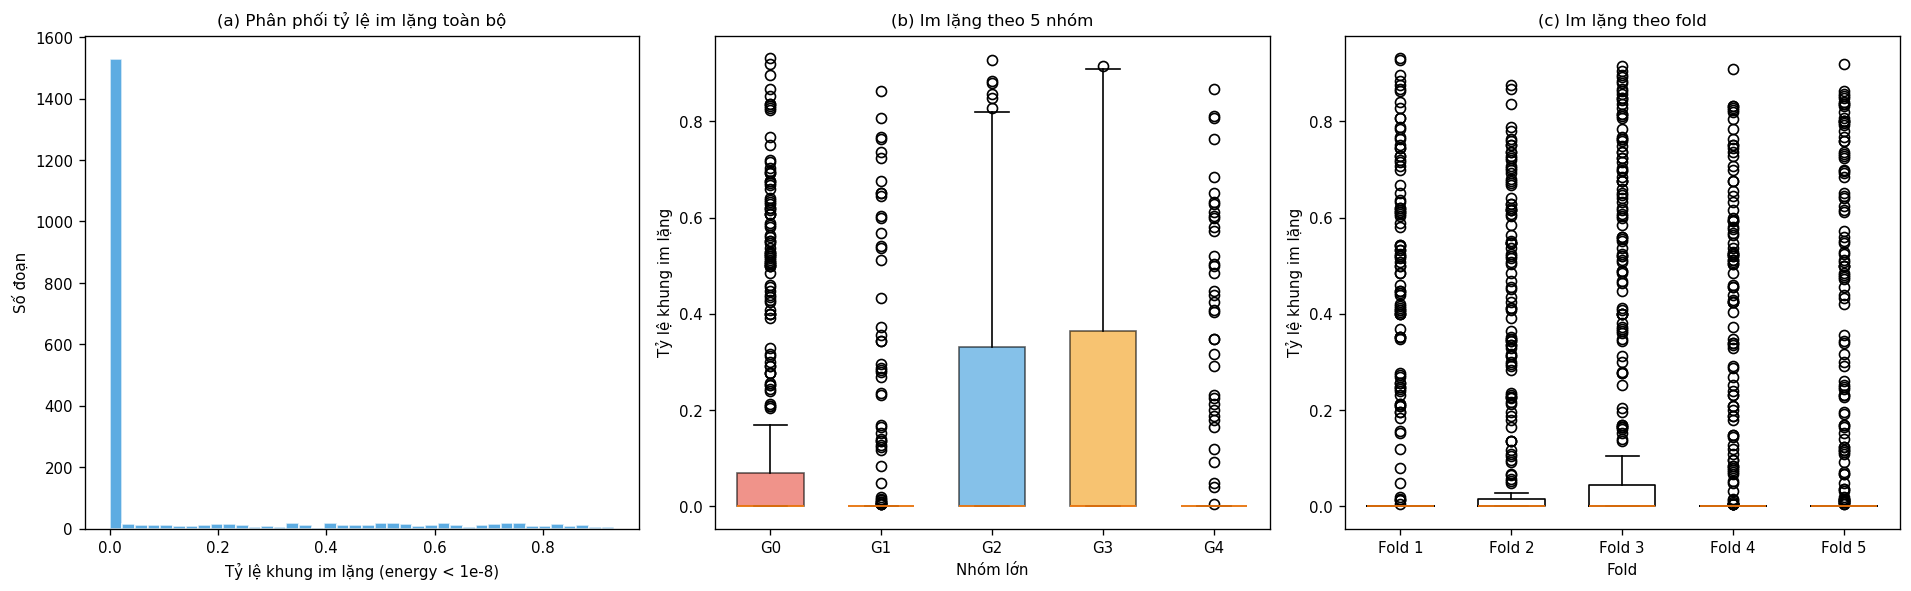


Top-10 lớp có tỷ lệ im lặng cao nhất:
  glass_breaking             0.558
  sneezing                   0.482
  door_wood_knock            0.409
  coughing                   0.403
  rooster                    0.398
  can_opening                0.350
  car_horn                   0.246
  drinking_sipping           0.237
  mouse_click                0.232
  water_drops                0.224


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Histogram tổng
axes[0].hist(sil_df["below_thr_ratio"], bins=40, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Tỷ lệ khung im lặng (energy < 1e-8)")
axes[0].set_ylabel("Số đoạn")
axes[0].set_title("(a) Phân phối tỷ lệ im lặng toàn bộ")

# (b) Theo 5 nhóm
group_data = [sil_df[sil_df["coarse"]==c]["below_thr_ratio"].values for c in range(5)]
bp = boxplot_labeled(axes[1], group_data, [f"G{c}" for c in range(5)],
                     patch_artist=True, widths=0.6)
for patch, color in zip(bp["boxes"], GROUP_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_xlabel("Nhóm lớn")
axes[1].set_ylabel("Tỷ lệ khung im lặng")
axes[1].set_title("(b) Im lặng theo 5 nhóm")

# (c) Theo fold
fold_data = [sil_df[sil_df["fold"]==f]["below_thr_ratio"].values for f in range(1,6)]
boxplot_labeled(axes[2], fold_data, [f"Fold {f}" for f in range(1,6)], widths=0.6)
axes[2].set_xlabel("Fold")
axes[2].set_ylabel("Tỷ lệ khung im lặng")
axes[2].set_title("(c) Im lặng theo fold")

plt.tight_layout()
fig.savefig(FIG_DIR / "silence_distribution.png", bbox_inches="tight")
plt.show()

# Top-10 lớp im lặng nhiều nhất
class_silence = sil_df.groupby("category")["below_thr_ratio"].mean().sort_values(ascending=False)
print("\nTop-10 lớp có tỷ lệ im lặng cao nhất:")
for cat, val in class_silence.head(10).items():
    print(f"  {cat:25s}  {val:.3f}")


In [9]:
# %% 2.3  Kiểm tra sàn log và tỷ lệ giá trị sàn
n_frames_total = 250
npy_files = sorted(list(LOGMEL_CACHE.glob("*.npy")))

# Đo trên 200 file đầu theo tên (Fold 1)
n_below_200, samples_200 = 0, 0
for npy_file in npy_files[:200]:
    S = np.load(npy_file)
    n_below_200 += (S <= -99.0).sum()
    samples_200 += S.size
pct_200 = n_below_200 / samples_200 * 100 if samples_200 > 0 else 0

# Đo trên toàn bộ 2,000 file (5 Folds)
n_below_all, samples_all = 0, 0
for npy_file in npy_files:
    S = np.load(npy_file)
    n_below_all += (S <= -99.0).sum()
    samples_all += S.size
pct_all = n_below_all / samples_all * 100 if samples_all > 0 else 0

print(f"Kiểm tra phân phối sàn log:")
print(f"  - 200 file đầu theo tên (Fold 1): {pct_200:.2f}% giá trị ≤ −99 dB (gần sàn 10·log10(1e-10))")
print(f"  - Toàn bộ 2 000 file (5 Folds):     {pct_all:.2f}% giá trị ≤ −99 dB ({n_below_all:,} / {samples_all:,})")
print("\n[QUYẾT ĐỊNH VỀ SÀN LOG]:")
print("  - Tỷ lệ sàn log toàn cục (~10.19%) tập trung ở các đoạn có khoảng lặng tự nhiên (tiếng gõ, côn trùng, v.v.).")
print("  - Lý do giữ nguyên sàn 10⁻¹⁰ (-100 dB): Khớp hoàn toàn đề cương và chuẩn tiền xử lý âm thanh phổ biến (librosa/torchaudio), đảm bảo ổn định gradient và tính so sánh.")
print("  - Hướng mở rộng: Đề xuất cấu hình log(E + ε) hoặc loại khung im lặng khi tính μ/σ cho các bài toán âm thanh có khoảng lặng dài (>80%).")


Kiểm tra phân phối sàn log:
  - 200 file đầu theo tên (Fold 1): 10.92% giá trị ≤ −99 dB (gần sàn 10·log10(1e-10))
  - Toàn bộ 2 000 file (5 Folds):     10.19% giá trị ≤ −99 dB (3,273,238 / 32,128,000)

[QUYẾT ĐỊNH VỀ SÀN LOG]:
  - Tỷ lệ sàn log toàn cục (~10.19%) tập trung ở các đoạn có khoảng lặng tự nhiên (tiếng gõ, côn trùng, v.v.).
  - Lý do giữ nguyên sàn 10⁻¹⁰ (-100 dB): Khớp hoàn toàn đề cương và chuẩn tiền xử lý âm thanh phổ biến (librosa/torchaudio), đảm bảo ổn định gradient và tính so sánh.
  - Hướng mở rộng: Đề xuất cấu hình log(E + ε) hoặc loại khung im lặng khi tính μ/σ cho các bài toán âm thanh có khoảng lặng dài (>80%).


### 3 · Phân phối log-mel và chuẩn hóa


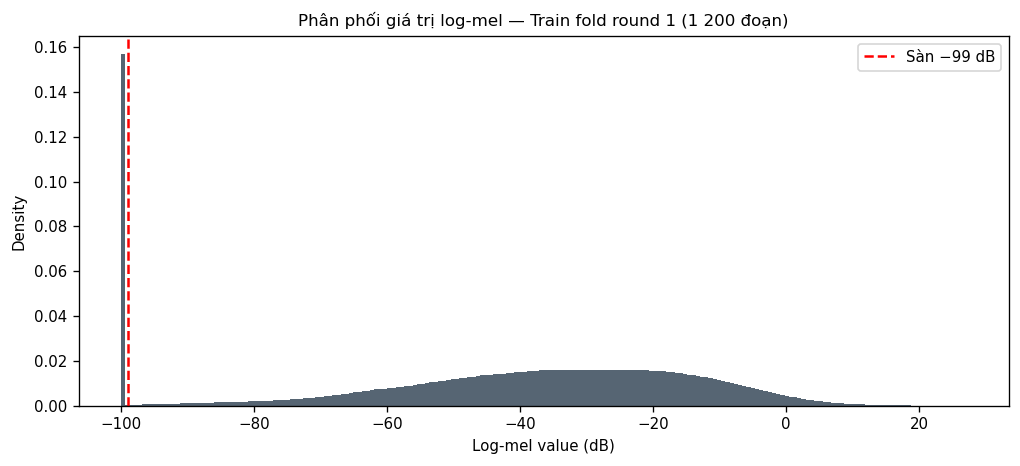

Min=-100.0  Max=27.1  Mean=-41.0  Std=27.9


In [10]:
manifest_r1 = pd.read_csv(MANIFEST_DIR / "round_1.csv")
train_r1 = manifest_r1[manifest_r1["split"]=="train"]

all_vals = []
for _, row in train_r1.iterrows():
    base = row["filename"].replace(".wav",".npy")
    S = np.load(LOGMEL_CACHE / base)
    all_vals.append(S.ravel())
all_vals = np.concatenate(all_vals)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_vals, bins=200, color="#2c3e50", edgecolor="none", alpha=0.8, density=True)
ax.axvline(x=-99, color="red", ls="--", label="Sàn −99 dB")
ax.set_xlabel("Log-mel value (dB)")
ax.set_ylabel("Density")
ax.set_title("Phân phối giá trị log-mel — Train fold round 1 (1 200 đoạn)")
ax.legend()
fig.savefig(FIG_DIR / "logmel_histogram.png", bbox_inches="tight")
plt.show()
print(f"Min={all_vals.min():.1f}  Max={all_vals.max():.1f}  Mean={all_vals.mean():.1f}  Std={all_vals.std():.1f}")


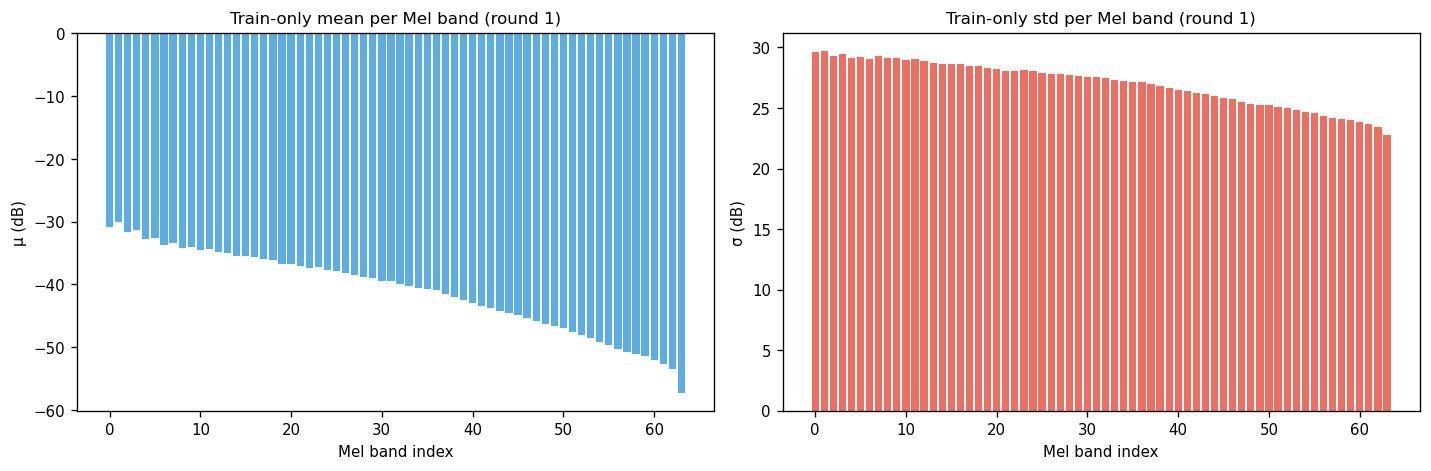

μ range: [-57.3, -30.0]  |  σ range: [22.7, 29.7]


In [11]:
stats_r1 = np.load(STATS_DIR / "stats_round_1.npz")
mu = stats_r1["mean"].squeeze()    # (64,)
sigma = stats_r1["std"].squeeze()  # (64,)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(64), mu, color="#3498db", alpha=0.8)
axes[0].set_xlabel("Mel band index")
axes[0].set_ylabel("μ (dB)")
axes[0].set_title("Train-only mean per Mel band (round 1)")

axes[1].bar(range(64), sigma, color="#e74c3c", alpha=0.8)
axes[1].set_xlabel("Mel band index")
axes[1].set_ylabel("σ (dB)")
axes[1].set_title("Train-only std per Mel band (round 1)")
plt.tight_layout()
fig.savefig(FIG_DIR / "mel_band_stats.png", bbox_inches="tight")
plt.show()

print(f"μ range: [{mu.min():.1f}, {mu.max():.1f}]  |  σ range: [{sigma.min():.1f}, {sigma.max():.1f}]")
if sigma.min() < 0.5:
    print("⚠ Một số dải Mel có σ rất nhỏ → giá trị sau chuẩn hóa có thể rất lớn")


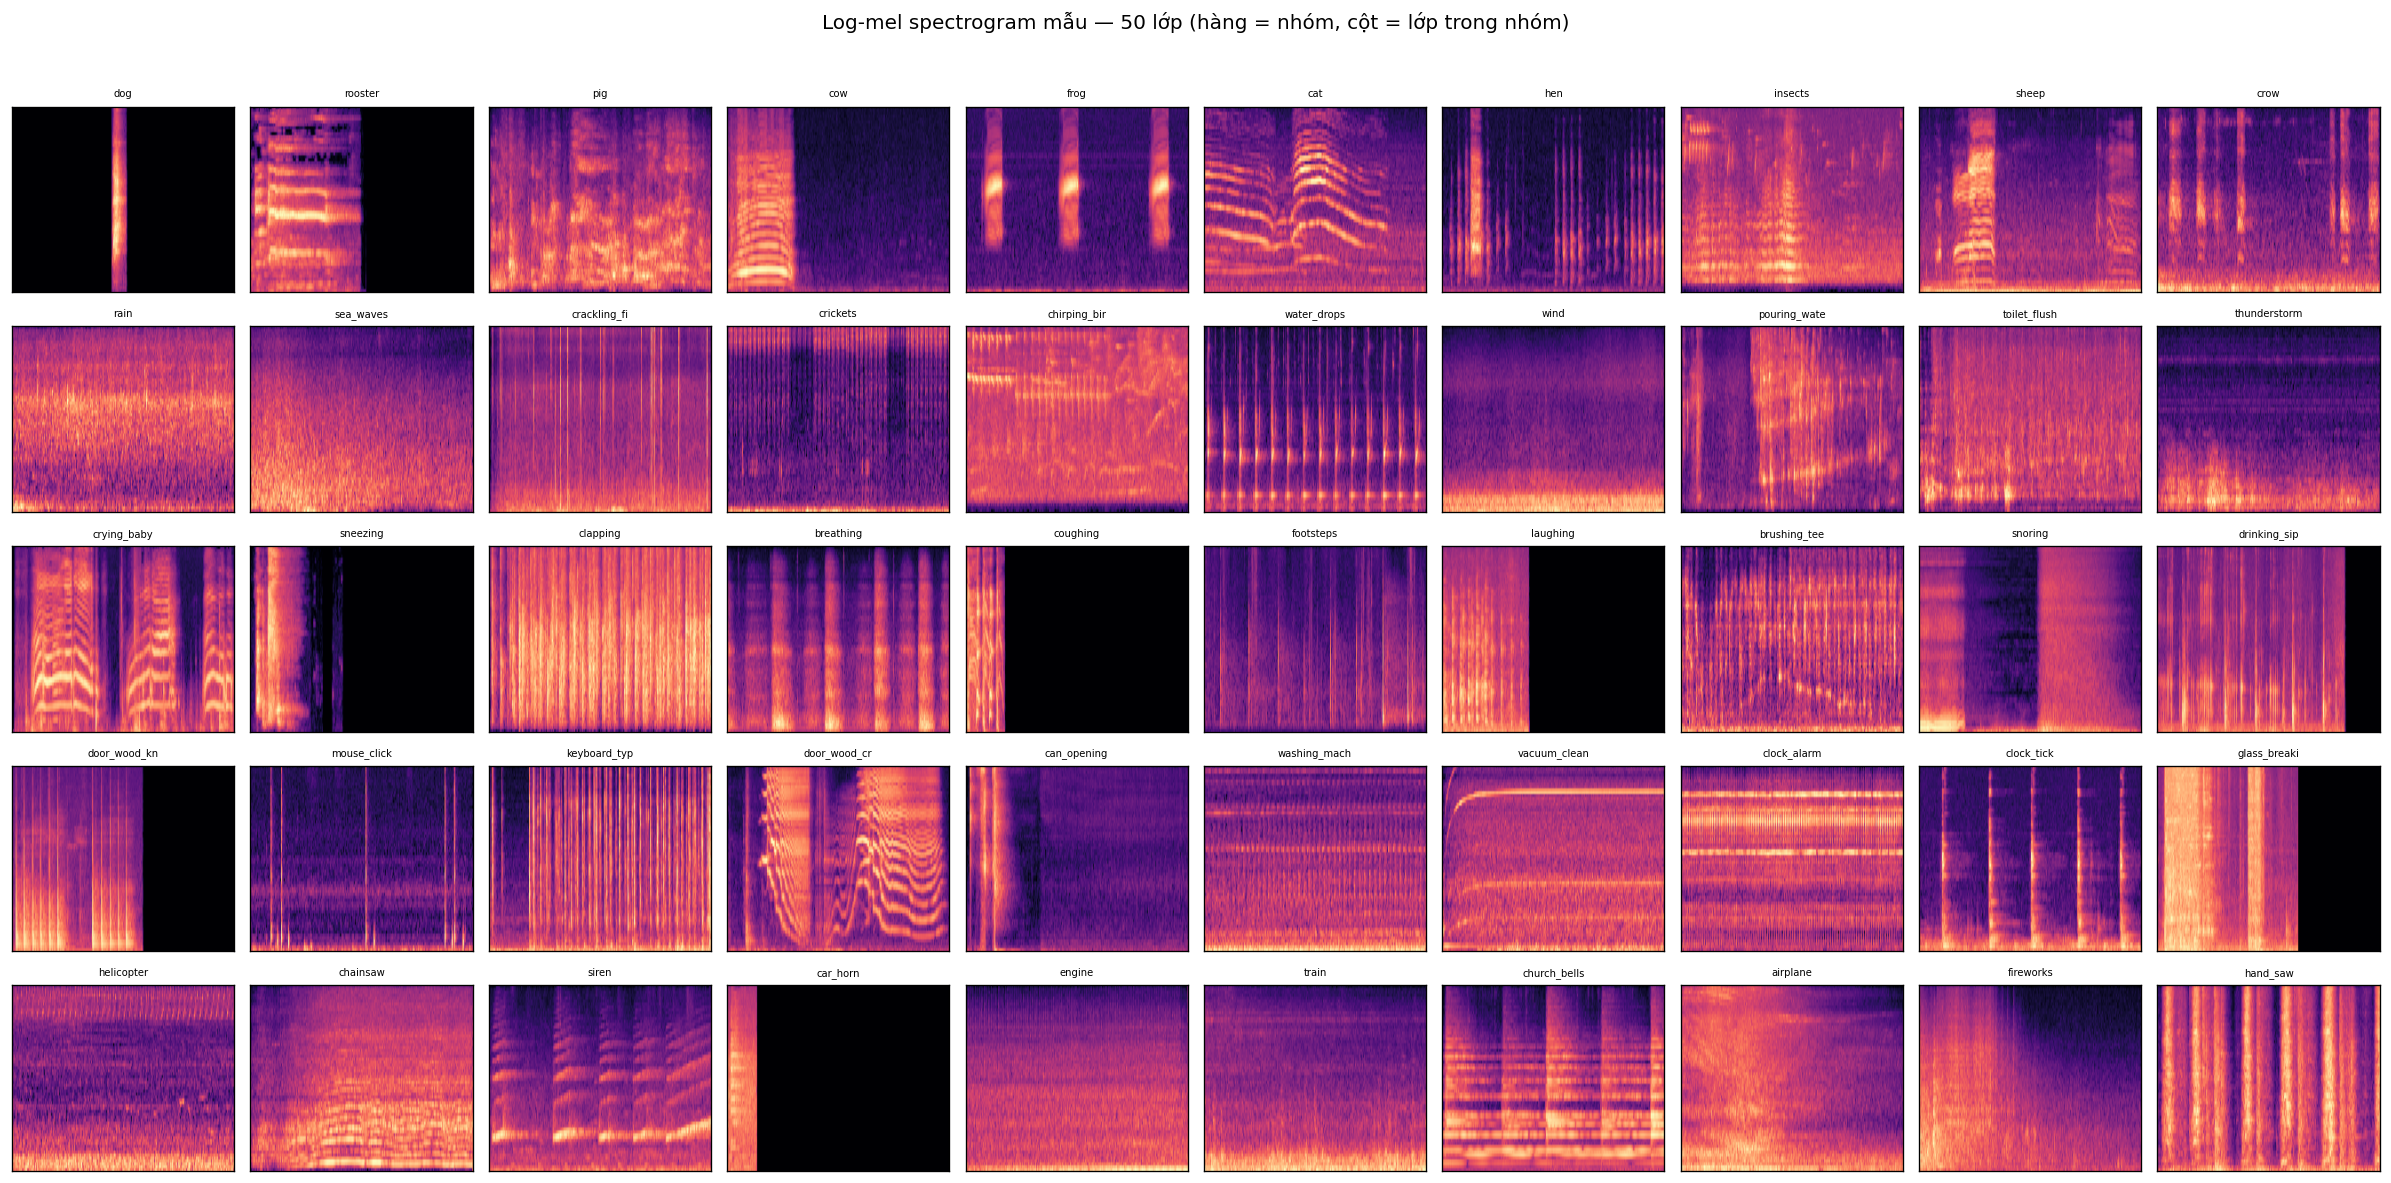

In [12]:
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
fig.suptitle("Log-mel spectrogram mẫu — 50 lớp (hàng = nhóm, cột = lớp trong nhóm)", fontsize=12)
for target_id in range(50):
    row_idx = target_id // 10
    col_idx = target_id % 10
    ax = axes[row_idx, col_idx]
    sample = df[df["target"]==target_id].iloc[0]
    npy_file = LOGMEL_CACHE / sample["filename"].replace(".wav",".npy")
    S = np.load(npy_file)
    ax.imshow(S, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"{sample['category'][:12]}", fontsize=6)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "logmel_grid_50classes.png", bbox_inches="tight")
plt.show()


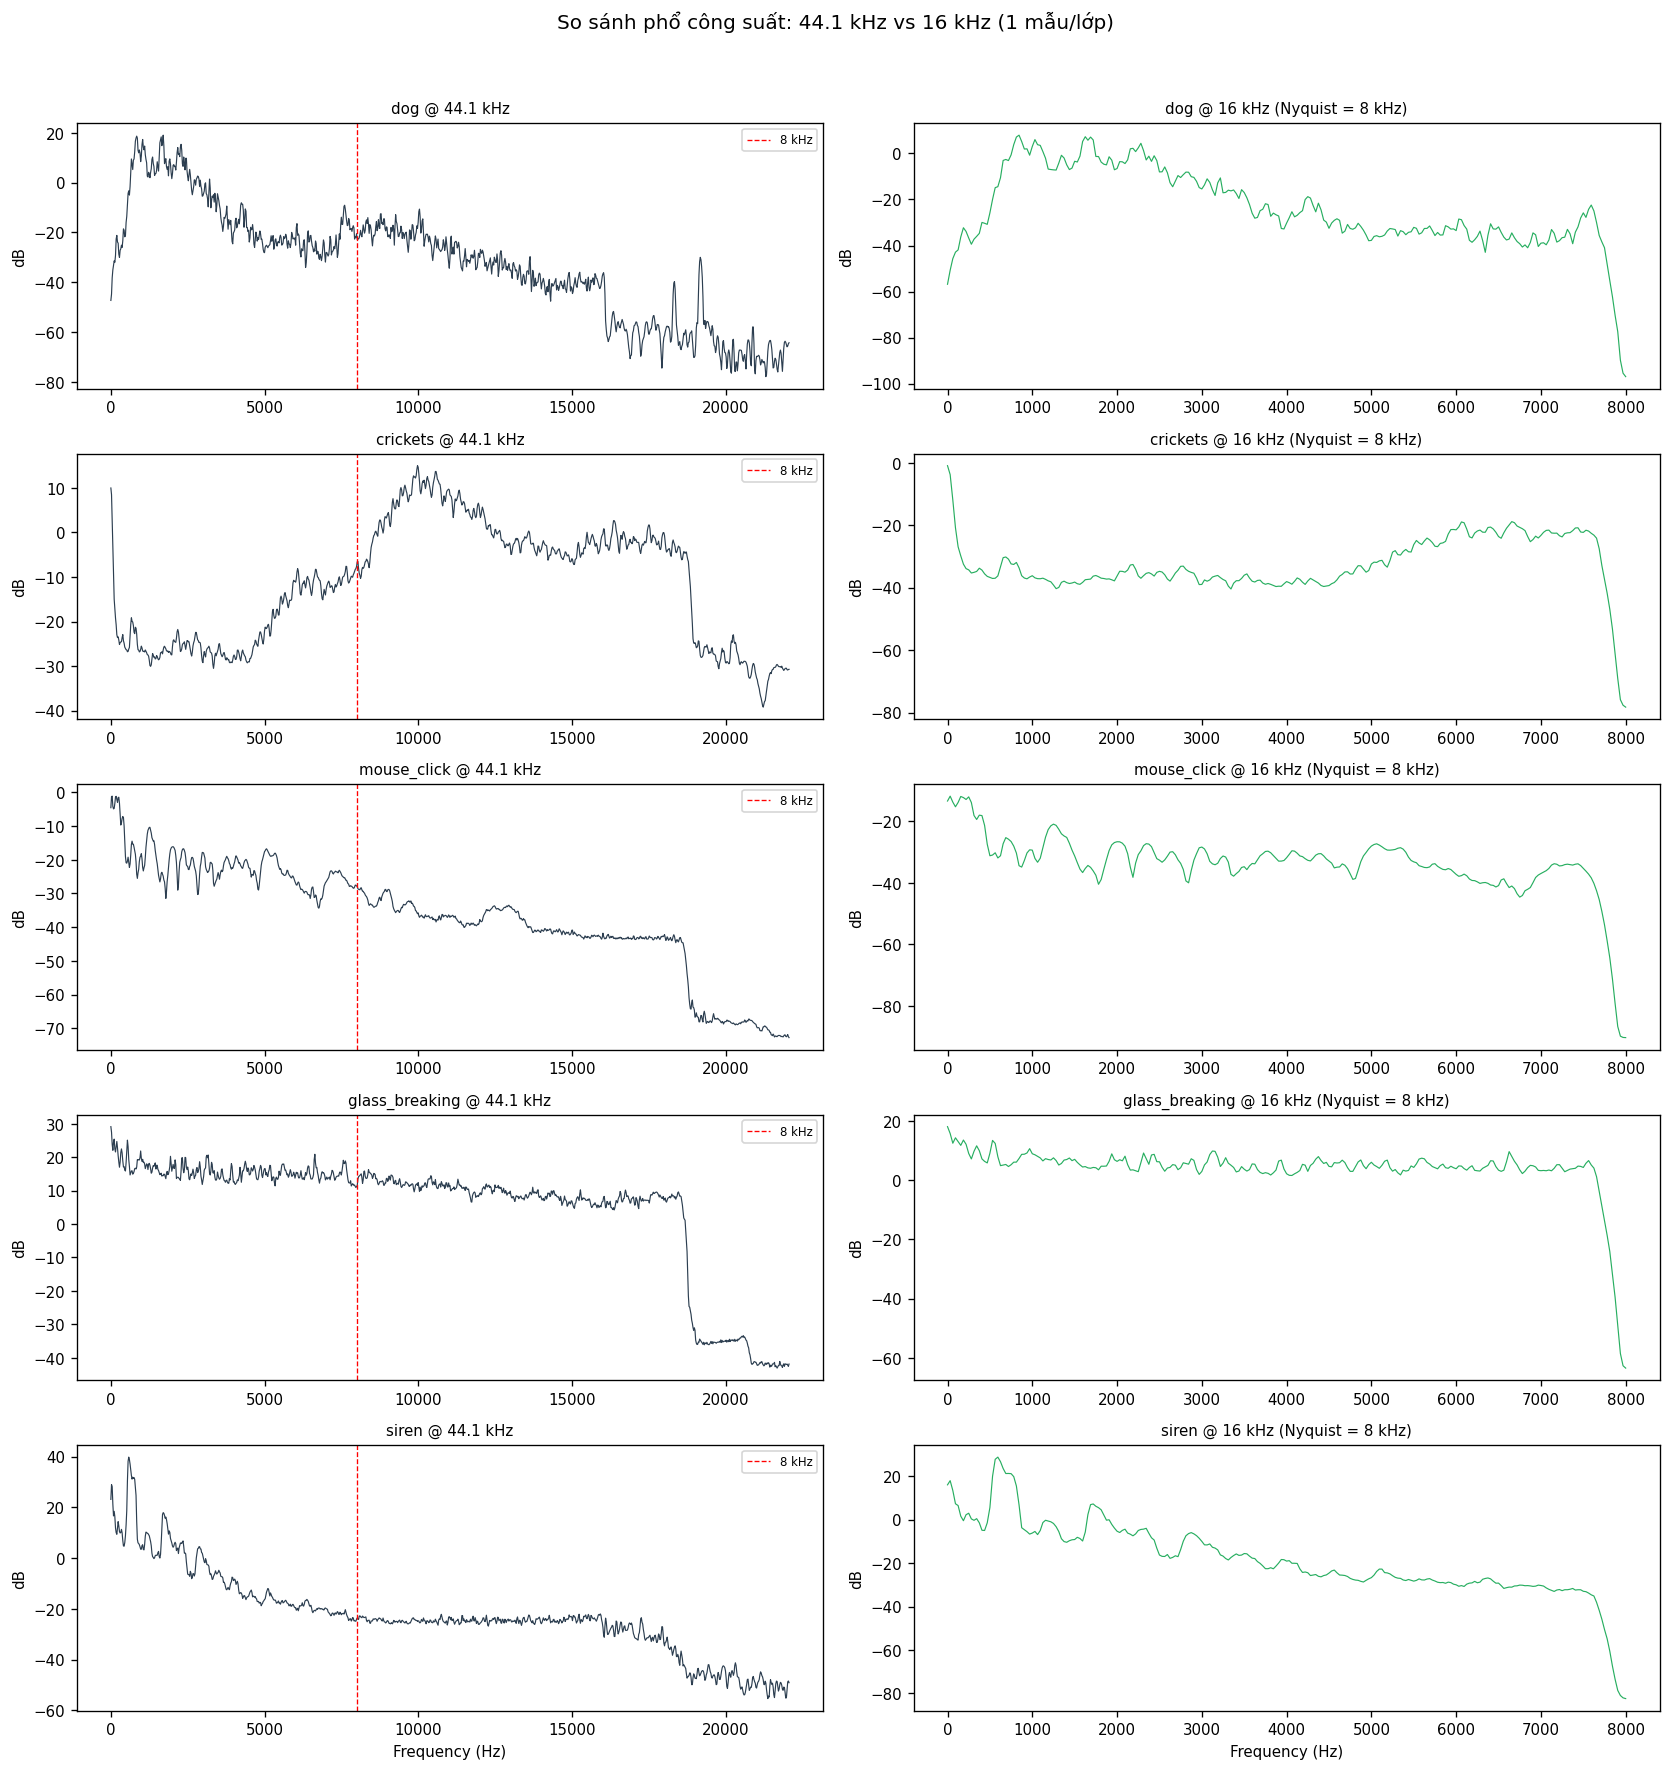


Năng lượng > 8 kHz (% tổng, ở bản gốc 44.1 kHz):
  crickets               97.96% ← đáng kể
  glass_breaking         21.92% ← đáng kể
  mouse_click             0.94%
  dog                     0.14%
  siren                   0.00%


In [13]:
test_classes = {0: "dog", 13: "crickets", 31: "mouse_click", 39: "glass_breaking", 42: "siren"}
fig, axes = plt.subplots(len(test_classes), 2, figsize=(14, 3*len(test_classes)))
fig.suptitle("So sánh phổ công suất: 44.1 kHz vs 16 kHz (1 mẫu/lớp)", fontsize=12)

energy_above_8k = {}
for idx, (tgt, name) in enumerate(test_classes.items()):
    sample_file = str(AUDIO_DIR / df[df["target"]==tgt].iloc[0]["filename"])
    
    y44, _ = librosa.load(sample_file, sr=44100)
    y16, _ = librosa.load(sample_file, sr=16000)
    
    S44 = np.abs(librosa.stft(y44, n_fft=2048))**2
    S16 = np.abs(librosa.stft(y16, n_fft=512))**2
    
    freqs44 = librosa.fft_frequencies(sr=44100, n_fft=2048)
    freqs16 = librosa.fft_frequencies(sr=16000, n_fft=512)
    
    mean_power44 = 10*np.log10(np.maximum(S44.mean(axis=1), 1e-10))
    mean_power16 = 10*np.log10(np.maximum(S16.mean(axis=1), 1e-10))
    
    axes[idx, 0].plot(freqs44, mean_power44, color="#2c3e50", linewidth=0.7)
    axes[idx, 0].axvline(8000, color="red", ls="--", lw=0.8, label="8 kHz")
    axes[idx, 0].set_title(f"{name} @ 44.1 kHz", fontsize=9)
    axes[idx, 0].set_ylabel("dB")
    axes[idx, 0].legend(fontsize=7)
    
    axes[idx, 1].plot(freqs16, mean_power16, color="#27ae60", linewidth=0.7)
    axes[idx, 1].set_title(f"{name} @ 16 kHz (Nyquist = 8 kHz)", fontsize=9)
    axes[idx, 1].set_ylabel("dB")
    
    # Tính % năng lượng > 8 kHz ở bản gốc 44.1 kHz
    mask_hi = freqs44 > 8000
    total_e = S44.mean(axis=1).sum()
    hi_e = S44.mean(axis=1)[mask_hi].sum()
    energy_above_8k[name] = hi_e / total_e * 100 if total_e > 0 else 0.0

axes[-1, 0].set_xlabel("Frequency (Hz)")
axes[-1, 1].set_xlabel("Frequency (Hz)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "spectral_comparison_resample.png", bbox_inches="tight")
plt.show()

print("\nNăng lượng > 8 kHz (% tổng, ở bản gốc 44.1 kHz):")
for name, pct in sorted(energy_above_8k.items(), key=lambda x: -x[1]):
    flag = " ← đáng kể" if pct > 5 else ""
    print(f"  {name:20s}  {pct:6.2f}%{flag}")


### 4 · Đặc trưng theo lớp & theo nhóm (gắn câu hỏi nghiên cứu)


Tính spectral features theo lớp (mất ~2 phút)...


  500/2000


  1000/2000


  1500/2000


  2000/2000


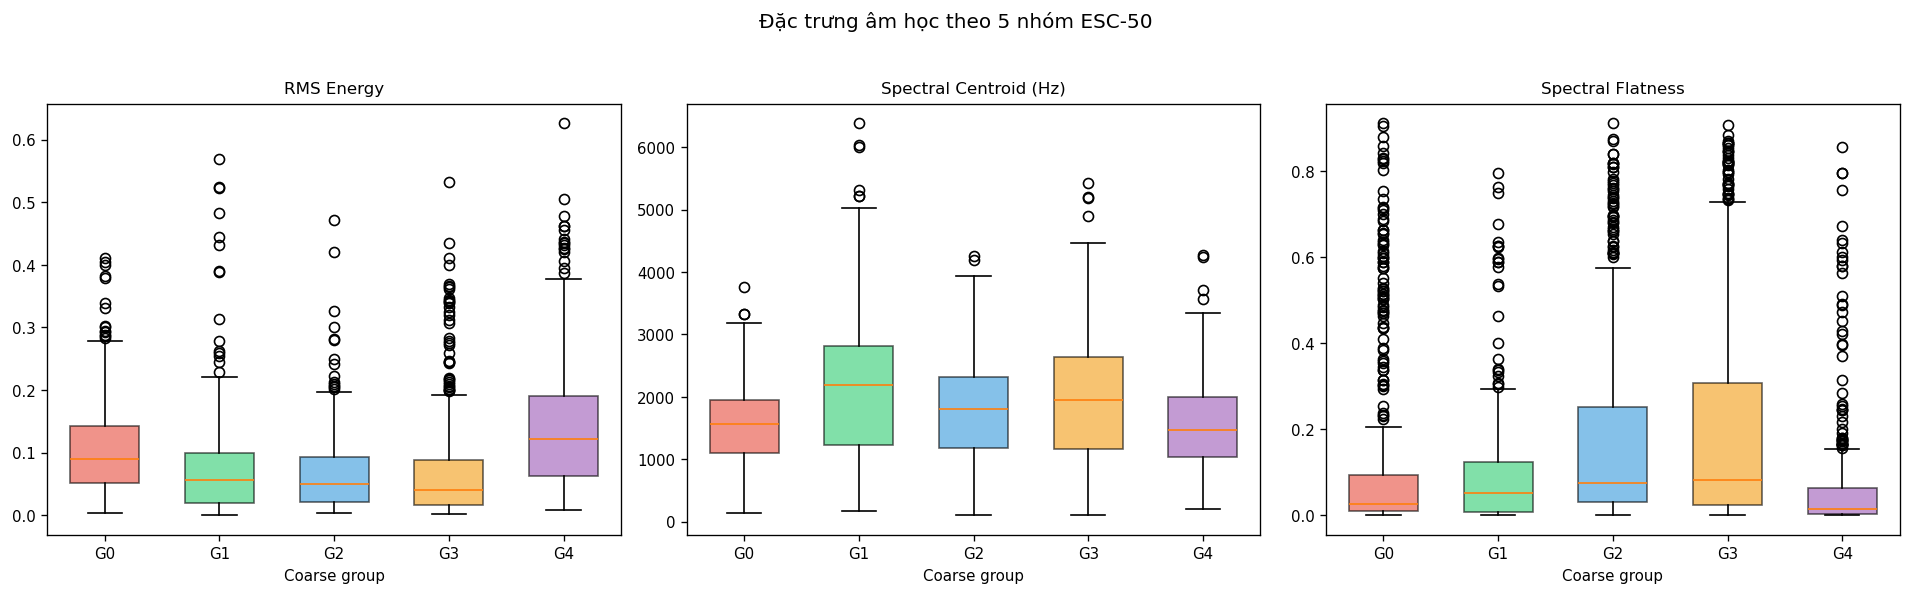

In [14]:
print("Tính spectral features theo lớp (mất ~2 phút)...")
feat_records = []
for i, row in df.iterrows():
    fpath = str(AUDIO_DIR / row["filename"])
    y, sr = librosa.load(fpath, sr=16000)
    if len(y) < 80000:
        y = np.pad(y, (0, 80000-len(y)))
    else:
        y = y[:80000]
    
    rms_val = float(np.sqrt(np.mean(y**2)))
    sc = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=16000)))
    sf = float(np.mean(librosa.feature.spectral_flatness(y=y)))
    
    feat_records.append({
        "target": row["target"], "category": row["category"],
        "coarse": g(row["target"]), "fold": row["fold"],
        "rms": rms_val, "spectral_centroid": sc, "spectral_flatness": sf,
    })
    if (i+1) % 500 == 0:
        print(f"  {i+1}/2000")

feat_df = pd.DataFrame(feat_records)

# Boxplot: spectral centroid theo 5 nhóm
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax_idx, (col, title) in enumerate([
    ("rms", "RMS Energy"), ("spectral_centroid", "Spectral Centroid (Hz)"),
    ("spectral_flatness", "Spectral Flatness")
]):
    data = [feat_df[feat_df["coarse"]==c][col].values for c in range(5)]
    bp = boxplot_labeled(axes[ax_idx], data, [f"G{c}" for c in range(5)],
                              patch_artist=True, widths=0.6)
    for patch, color in zip(bp["boxes"], GROUP_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    axes[ax_idx].set_title(title)
    axes[ax_idx].set_xlabel("Coarse group")
plt.suptitle("Đặc trưng âm học theo 5 nhóm ESC-50", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / "spectral_features_by_group.png", bbox_inches="tight")
plt.show()


Nạp MFCC 80-dim cho 2 000 đoạn...


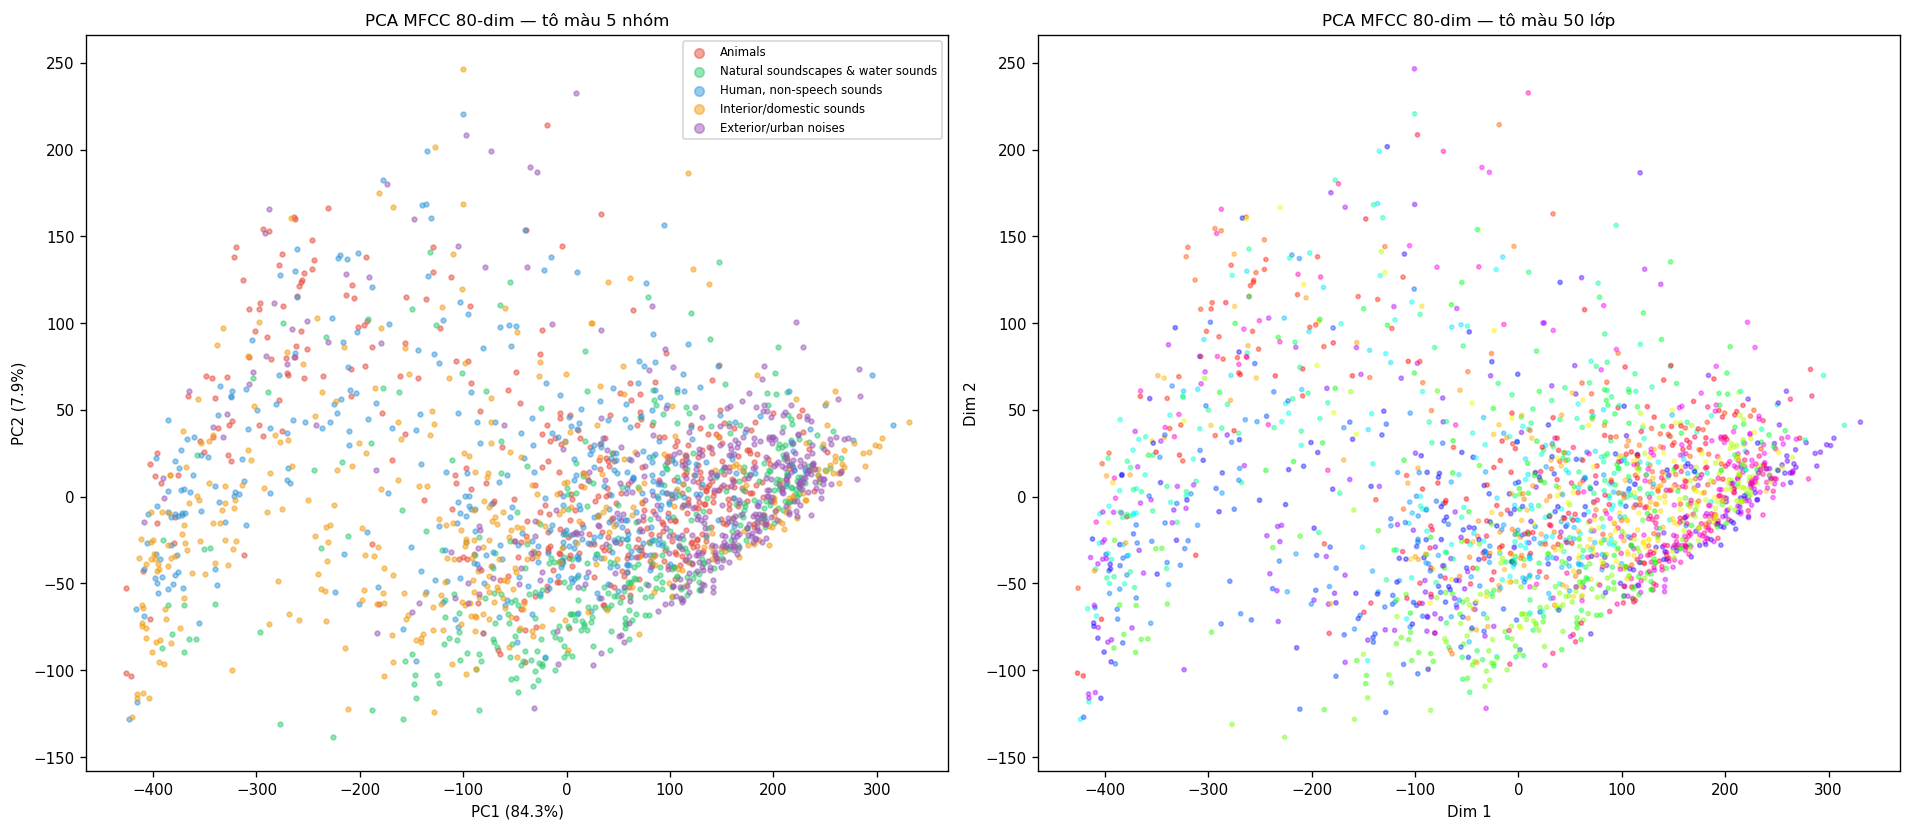

In [15]:
# Nạp toàn bộ MFCC 80-dim
print("Nạp MFCC 80-dim cho 2 000 đoạn...")
X_all = np.zeros((2000, 80), dtype=np.float32)
labels_fine = np.zeros(2000, dtype=int)
labels_coarse = np.zeros(2000, dtype=int)
categories = []
for i, row in df.iterrows():
    npy = MFCC_CACHE / row["filename"].replace(".wav",".npy")
    if npy.exists():
        X_all[i] = np.load(npy)
    else:
        # Extract if not cached
        S = np.load(LOGMEL_CACHE / row["filename"].replace(".wav",".npy"))
        mfcc = librosa.feature.mfcc(S=S, n_mfcc=40, dct_type=2, norm="ortho")
        feat = np.concatenate([mfcc.mean(1), mfcc.std(1)]).astype(np.float32)
        X_all[i] = feat
    labels_fine[i] = row["target"]
    labels_coarse[i] = g(row["target"])
    categories.append(row["category"])

# PCA
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_all)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Tô màu 5 nhóm
for c in range(5):
    mask = labels_coarse == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.5,
                    color=GROUP_COLORS[c], label=GROUP_NAMES[c])
axes[0].legend(fontsize=7, markerscale=2)
axes[0].set_title("PCA MFCC 80-dim — tô màu 5 nhóm")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# UMAP hoặc PCA-50 classes
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.3)
    X_2d = reducer.fit_transform(X_all)
    method_name = "UMAP"
else:
    X_2d = X_pca
    method_name = "PCA"

scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], s=6, alpha=0.4,
                          c=labels_fine, cmap="hsv", vmin=0, vmax=49)
axes[1].set_title(f"{method_name} MFCC 80-dim — tô màu 50 lớp")
axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.tight_layout()
fig.savefig(FIG_DIR / "mfcc_projection.png", bbox_inches="tight")
plt.show()


In [16]:
class_means = np.zeros((50, 80))
for k in range(50):
    class_means[k] = X_all[labels_fine == k].mean(axis=0)

from scipy.spatial.distance import cdist
D = cdist(class_means, class_means, metric="euclidean")
np.fill_diagonal(D, np.inf)

same_group_nearest = 0
for k in range(50):
    nearest = int(np.argmin(D[k]))
    if g(k) == g(nearest):
        same_group_nearest += 1

print(f"\nKhoảng cách MFCC giữa các lớp:")
print(f"  Tỷ lệ lớp gần nhất cùng nhóm: {same_group_nearest}/50 = {same_group_nearest/50*100:.0f}%")
if same_group_nearest < 30:
    print("  → Nhóm ESC-50 chủ yếu theo ngữ nghĩa, không theo cấu trúc âm học.")
    print("  → Kỳ vọng coarse head chỉ mang lợi ích nhỏ cho fine accuracy.")
else:
    print("  → Nhóm ESC-50 có phần trùng với cấu trúc âm học → coarse head có thể giúp ích.")



Khoảng cách MFCC giữa các lớp:
  Tỷ lệ lớp gần nhất cùng nhóm: 13/50 = 26%
  → Nhóm ESC-50 chủ yếu theo ngữ nghĩa, không theo cấu trúc âm học.
  → Kỳ vọng coarse head chỉ mang lợi ích nhỏ cho fine accuracy.


### 5 · Kiểm tra theo fold


Thống kê theo fold:
 fold  n_samples  n_src_files  silence_mean  silence_std  active_dur_mean
    1        400          311       0.11682     0.239378          4.41590
    2        400          302       0.10544     0.219274          4.47280
    3        400          308       0.13191     0.259922          4.34045
    4        400          297       0.09734     0.214459          4.51330
    5        400          310       0.10354     0.233167          4.48230


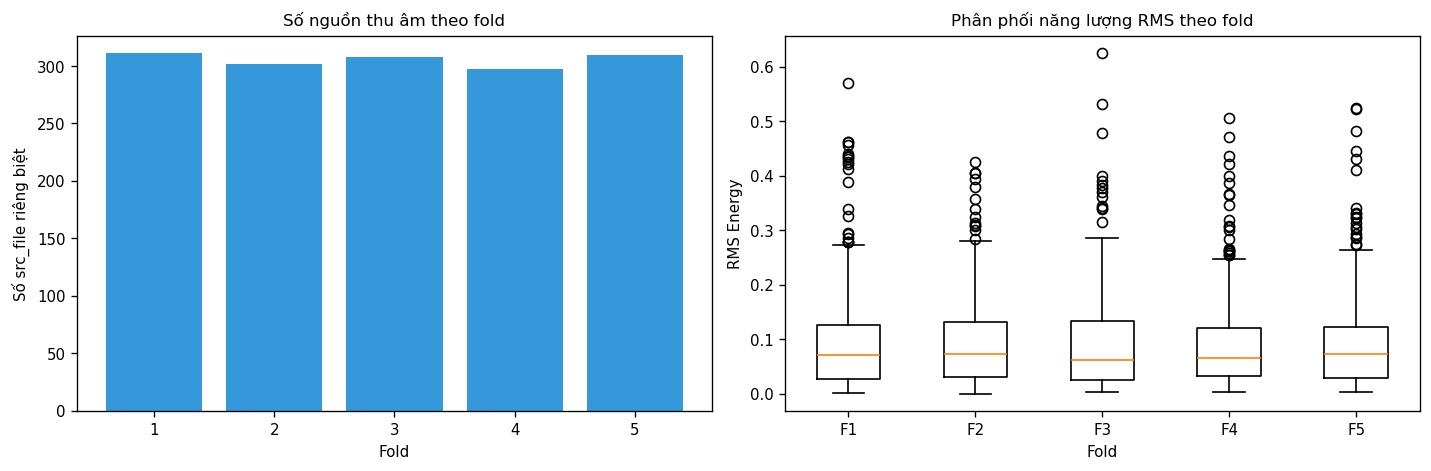

In [17]:
fold_stats = []
for fid in range(1, 6):
    fdf = sil_df[sil_df["fold"]==fid]
    n_src = df[df["fold"]==fid]["src_file"].nunique()
    fold_stats.append({
        "fold": fid,
        "n_samples": len(fdf),
        "n_src_files": n_src,
        "silence_mean": fdf["below_thr_ratio"].mean(),
        "silence_std": fdf["below_thr_ratio"].std(),
        "active_dur_mean": fdf["active_duration_sec"].mean(),
    })
fold_stats_df = pd.DataFrame(fold_stats)
print("Thống kê theo fold:")
print(fold_stats_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(fold_stats_df["fold"], fold_stats_df["n_src_files"], color="#3498db")
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("Số src_file riêng biệt")
axes[0].set_title("Số nguồn thu âm theo fold")

# RMS energy theo fold
rms_by_fold = [feat_df[feat_df["fold"]==f]["rms"].values for f in range(1,6)]
boxplot_labeled(axes[1], rms_by_fold, [f"F{f}" for f in range(1,6)])
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("RMS Energy")
axes[1].set_title("Phân phối năng lượng RMS theo fold")
plt.tight_layout()
fig.savefig(FIG_DIR / "fold_analysis.png", bbox_inches="tight")
plt.show()


### 6 · Kiểm tra nhanh bằng B0 (MFCC–SVM)


In [18]:
b0_results_path = REPORT_DIR / "results_b0_svm.csv"
if b0_results_path.exists():
    print("Đã có kết quả B0 → load từ file.")
    b0_df = pd.read_csv(b0_results_path)
    print(b0_df.to_string(index=False))
else:
    print("Chạy B0 từ đầu...")
    from src.models.baseline_svm import precompute_all_mfcc_80, load_features_for_split
    precompute_all_mfcc_80(str(LOGMEL_CACHE), str(MFCC_CACHE))
    
    b0_records = []
    all_b0_preds = []
    for rn in range(1, 6):
        manifest = str(MANIFEST_DIR / f"round_{rn}.csv")
        X_tr, y_tr, _, _ = load_features_for_split(manifest, "train", str(MFCC_CACHE))
        X_val, y_val, _, _ = load_features_for_split(manifest, "val", str(MFCC_CACHE))
        X_te, y_te, y_te_c, fnames = load_features_for_split(manifest, "test", str(MFCC_CACHE))
        
        scaler = StandardScaler().fit(X_tr)
        X_tr_s, X_val_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_val), scaler.transform(X_te)
        
        best_c, best_acc, best_clf = None, -1, None
        for c_val in [1.0, 10.0]:
            clf = SVC(C=c_val, kernel="rbf", gamma="scale", random_state=SEED)
            clf.fit(X_tr_s, y_tr)
            vacc = accuracy_score(y_val, clf.predict(X_val_s))
            if vacc > best_acc:
                best_c, best_acc, best_clf = c_val, vacc, clf
        
        preds = best_clf.predict(X_te_s)
        acc_f = accuracy_score(y_te, preds)
        f1_f  = f1_score(y_te, preds, average="macro", zero_division=0)
        acc_cm = accuracy_score(y_te_c, preds // 10)
        b0_records.append({"round":rn, "C":best_c, "Acc_fine":acc_f, "F1":f1_f, "Acc_coarse_map":acc_cm})
        
        for fn, yt, yp in zip(fnames, y_te, preds):
            all_b0_preds.append({"filename":fn,"y_true":yt,"y_pred":yp,"fold":rn})
        print(f"  Round {rn}: C={best_c}, Acc={acc_f*100:.2f}%, F1={f1_f*100:.2f}%")
    
    b0_df = pd.DataFrame(b0_records)
    b0_df.to_csv(b0_results_path, index=False)
    pd.DataFrame(all_b0_preds).to_csv(PRED_DIR / "b0_out_of_fold.csv", index=False)
    print(b0_df.to_string(index=False))


Đã có kết quả B0 → load từ file.
round test_fold selected_C  val_acc_fine  Acc_fine  Macro-F1_fine  Acc_coarse_map  Acc_coarse_head  HCR_raw  intra_group_error_rate  inter_group_error_rate
    1         1       10.0       0.38250  0.367500       0.347343        0.577500              NaN      NaN                0.332016                0.667984
    2         2       10.0       0.44250  0.397500       0.375579        0.557500              NaN      NaN                0.265560                0.734440
    3         3       10.0       0.49000  0.402500       0.390016        0.567500              NaN      NaN                0.276151                0.723849
    4         4       10.0       0.39750  0.507500       0.481748        0.657500              NaN      NaN                0.304569                0.695431
    5         5       10.0       0.38250  0.412500       0.395922        0.575000              NaN      NaN                0.276596                0.723404
 Mean       All          -     

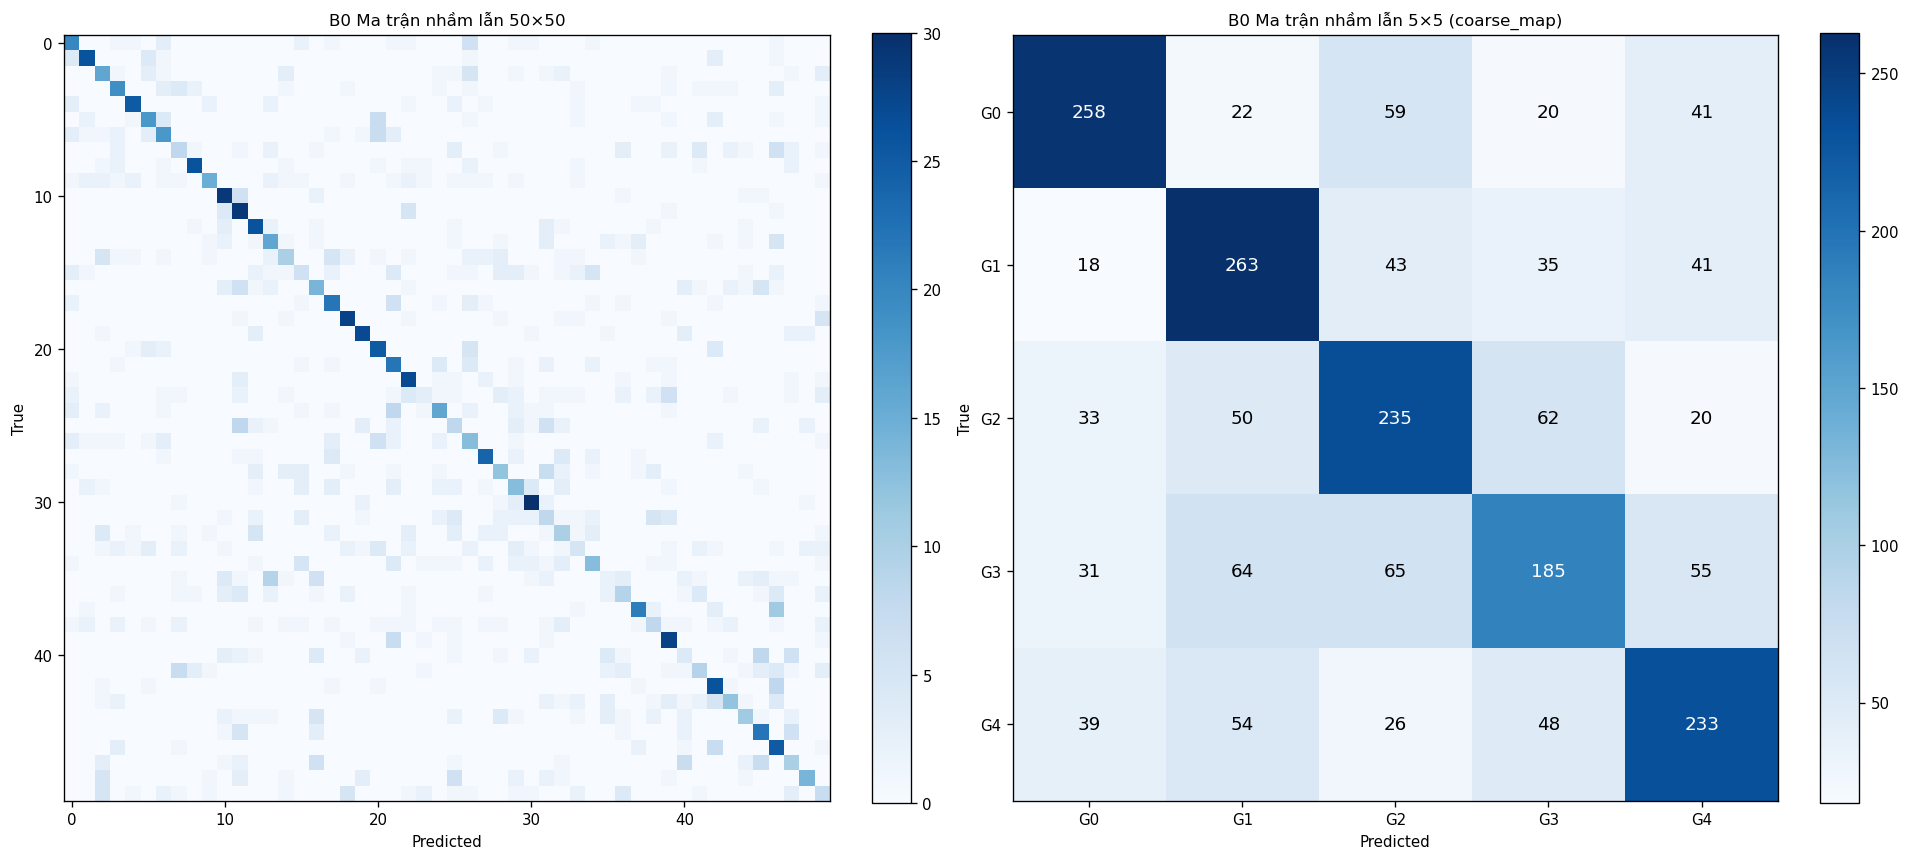


Top-10 cặp lớp B0 nhầm nhiều nhất:
  clock_alarm          → church_bells          (11 lần, KHÁC nhóm)
  washing_machine      → crickets              (9 lần, KHÁC nhóm)
  coughing             → sneezing              (8 lần, cùng nhóm)
  footsteps            → sea_waves             (8 lần, KHÁC nhóm)
  helicopter           → train                 (8 lần, cùng nhóm)
  siren                → church_bells          (8 lần, cùng nhóm)
  cat                  → crying_baby           (7 lần, KHÁC nhóm)
  hen                  → crying_baby           (7 lần, KHÁC nhóm)
  snoring              → mouse_click           (7 lần, KHÁC nhóm)
  glass_breaking       → sneezing              (7 lần, KHÁC nhóm)


In [19]:
oof_path = PRED_DIR / "b0_out_of_fold.csv"
if oof_path.exists():
    oof = pd.read_csv(oof_path)
    # Tìm cột dự đoán fine
    pred_col = "y_pred" if "y_pred" in oof.columns else "y_fine_pred"
    true_col = "y_true" if "y_true" in oof.columns else "y_fine_true"
    
    y_true_f = oof[true_col].values
    y_pred_f = oof[pred_col].values
    
    cm50 = confusion_matrix(y_true_f, y_pred_f, labels=list(range(50)))
    cm5  = confusion_matrix(y_true_f // 10, y_pred_f // 10, labels=list(range(5)))
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    im0 = axes[0].imshow(cm50, cmap="Blues", interpolation="nearest")
    axes[0].set_title("B0 Ma trận nhầm lẫn 50×50")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    im1 = axes[1].imshow(cm5, cmap="Blues", interpolation="nearest")
    for i in range(5):
        for j in range(5):
            axes[1].text(j, i, str(cm5[i,j]), ha="center", va="center",
                        fontsize=11, color="white" if cm5[i,j] > cm5.max()/2 else "black")
    axes[1].set_xticks(range(5)); axes[1].set_yticks(range(5))
    axes[1].set_xticklabels([f"G{i}" for i in range(5)])
    axes[1].set_yticklabels([f"G{i}" for i in range(5)])
    axes[1].set_title("B0 Ma trận nhầm lẫn 5×5 (coarse_map)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    plt.tight_layout()
    fig.savefig(FIG_DIR / "b0_confusion_matrices.png", bbox_inches="tight")
    plt.show()
    
    # Cặp lớp nhầm nhiều nhất
    cm_no_diag = cm50.copy()
    np.fill_diagonal(cm_no_diag, 0)
    top_confused = []
    for _ in range(10):
        i, j = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
        top_confused.append((int(i), int(j), int(cm_no_diag[i, j])))
        cm_no_diag[i, j] = 0
    print("\nTop-10 cặp lớp B0 nhầm nhiều nhất:")
    for i, j, cnt in top_confused:
        same = "cùng nhóm" if g(i) == g(j) else "KHÁC nhóm"
        print(f"  {FINE_CLASSES[i]:20s} → {FINE_CLASSES[j]:20s}  ({cnt} lần, {same})")
else:
    print("Chưa có file out-of-fold B0, hãy chạy cell 6.1 trước.")


### Bảng Phát hiện → Quyết định


In [20]:
# %% Bảng Phát hiện → Quyết định
print("=" * 85)
print("  BẢNG PHÁT HIỆN → QUYẾT ĐỊNH TRONG EDA")
print("=" * 85)
b0_acc_str = f"{b0_df['Acc_fine'].iloc[:5].astype(float).mean()*100:.2f}%" if 'Acc_fine' in b0_df.columns else "~41.75%"
findings = [
    ("Rò rỉ nguồn (Source leakage)",
     "4 src_file ở 2 fold khác nhau (khác lớp)",
     "Assert cùng lớp đạt (không rò nhãn); chấp nhận phân chia chuẩn ESC-50 và ghi rò đặc trưng âm học vào Hạn chế."),
    ("Tỷ lệ giá trị ≤ −99 dB (sàn log)",
     f"{pct_all:.2f}% toàn cục ({pct_200:.2f}% trên 200 file đầu)",
     "Giữ nguyên sàn 10⁻¹⁰ để khớp đề cương và chuẩn librosa; đề xuất log(E+ε) vào hướng mở rộng."),
    ("Lớp có tỷ lệ im lặng cao nhất",
     f"{class_silence.index[0]} ({class_silence.iloc[0]:.2f})",
     "Ghi vào hạn chế, mạng có thể tận dụng tỷ lệ im lặng như đặc trưng phân loại."),
    ("Năng lượng > 8 kHz đáng kể",
     ", ".join([n for n,p in energy_above_8k.items() if p > 5]) or "Không có lớp > 5%",
     "Resample 16 kHz là hợp lý cho IoT/TinyML; ghi nhận mất băng thông > 8 kHz vào hạn chế."),
    ("Nhóm ESC-50 tạo cụm âm học",
     f"{same_group_nearest}/50 lớp gần nhất cùng nhóm",
     "Kỳ vọng M1 ít cải thiện fine accuracy do 5 nhóm chia theo ngữ nghĩa thế giới thực hơn là âm học."),
    ("Độ lệch năng lượng giữa các fold",
     "Phân phối RMS đồng đều (xem hình fold_analysis)",
     "5 fold cân bằng, sẵn sàng cho giao thức 3/1/1 fold cross-validation."),
    ("B0 Acc_fine (MFCC-SVM Baseline)",
     b0_acc_str,
     "Baseline hợp lý, mốc đối chứng tin cậy để đánh giá hiệu quả của CNN."),
]
for finding, value, decision in findings:
    print(f"\n  • Phát hiện: {finding}")
    print(f"    Giá trị:   {value}")
    print(f"    Quyết định: {decision}")
print("\n" + "=" * 85)


  BẢNG PHÁT HIỆN → QUYẾT ĐỊNH TRONG EDA

  • Phát hiện: Rò rỉ nguồn (Source leakage)
    Giá trị:   4 src_file ở 2 fold khác nhau (khác lớp)
    Quyết định: Assert cùng lớp đạt (không rò nhãn); chấp nhận phân chia chuẩn ESC-50 và ghi rò đặc trưng âm học vào Hạn chế.

  • Phát hiện: Tỷ lệ giá trị ≤ −99 dB (sàn log)
    Giá trị:   10.19% toàn cục (10.92% trên 200 file đầu)
    Quyết định: Giữ nguyên sàn 10⁻¹⁰ để khớp đề cương và chuẩn librosa; đề xuất log(E+ε) vào hướng mở rộng.

  • Phát hiện: Lớp có tỷ lệ im lặng cao nhất
    Giá trị:   glass_breaking (0.56)
    Quyết định: Ghi vào hạn chế, mạng có thể tận dụng tỷ lệ im lặng như đặc trưng phân loại.

  • Phát hiện: Năng lượng > 8 kHz đáng kể
    Giá trị:   crickets, glass_breaking
    Quyết định: Resample 16 kHz là hợp lý cho IoT/TinyML; ghi nhận mất băng thông > 8 kHz vào hạn chế.

  • Phát hiện: Nhóm ESC-50 tạo cụm âm học
    Giá trị:   13/50 lớp gần nhất cùng nhóm
    Quyết định: Kỳ vọng M1 ít cải thiện fine accuracy do 5 nhóm chia 

---
## PART 2 — TRAINING
---


### Thiết lập chung cho huấn luyện CNN


In [21]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class ESC50Dataset(Dataset):
    """Dataset cho CNN training."""
    def __init__(self, manifest_path, split, stats_file, cache_dir, augment=False):
        df_m = pd.read_csv(manifest_path)
        self.df = df_m[df_m["split"]==split].reset_index(drop=True)
        self.cache_dir = Path(cache_dir)
        self.augment = augment
        stats = np.load(stats_file)
        self.mean = stats["mean"]  # (64,1)
        self.std  = stats["std"]   # (64,1)
    
    def __len__(self): return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        S = np.load(self.cache_dir / row["filename"].replace(".wav",".npy"))  # (64,251)
        S_norm = (S - self.mean) / self.std
        
        if self.augment:
            # SpecAugment: 1 freq mask [0,8], 1 time mask [0,25], set to 0
            S_norm = S_norm.copy()
            f_w = np.random.randint(0, 9)
            if f_w > 0:
                f_s = np.random.randint(0, 64 - f_w + 1)
                S_norm[f_s:f_s+f_w, :] = 0.0
            t_w = np.random.randint(0, 26)
            if t_w > 0:
                t_s = np.random.randint(0, 251 - t_w + 1)
                S_norm[:, t_s:t_s+t_w] = 0.0
        
        x = torch.from_numpy(S_norm).unsqueeze(0).float()  # (1,64,251)
        return {
            "x": x,
            "y_fine": torch.tensor(row["target"], dtype=torch.long),
            "y_coarse": torch.tensor(row["coarse_target"], dtype=torch.long),
            "filename": row["filename"],
        }


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, 3, stride=2, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_c)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x): return self.relu(self.bn(self.conv(x)))


class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.blocks = nn.Sequential(
            ConvBlock(1, 16), ConvBlock(16, 32),
            ConvBlock(32, 64), ConvBlock(64, 96),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.2)
    def forward(self, x):
        x = self.blocks(x)
        x = self.gap(x)
        return self.drop(torch.flatten(x, 1))


class SingleTaskCNN(nn.Module):
    """B1: backbone + fine head only."""
    def __init__(self):
        super().__init__()
        self.backbone = Backbone()
        self.fine_head = nn.Linear(96, 50)
    def forward(self, x):
        return self.fine_head(self.backbone(x))


class MultiTaskCNN(nn.Module):
    """M1/M2: backbone + fine head + coarse head."""
    def __init__(self):
        super().__init__()
        self.backbone = Backbone()
        self.fine_head = nn.Linear(96, 50)
        self.coarse_head = nn.Linear(96, 5)
    def forward(self, x):
        h = self.backbone(x)
        return self.fine_head(h), self.coarse_head(h)


def train_one_epoch(model, loader, optimizer, device, model_type,
                    lambda_c=0.3, lambda_h=0.1, M_mat=None):
    model.train()
    total_loss, total_loss_f, correct, total = 0., 0., 0, 0
    for batch in loader:
        x = batch["x"].to(device)
        y_f = batch["y_fine"].to(device)
        y_c = batch["y_coarse"].to(device)
        optimizer.zero_grad()
        
        if model_type == "B1":
            z_f = model(x)
            loss_f = F.cross_entropy(z_f, y_f)
            loss = loss_f
        else:
            z_f, z_c = model(x)
            loss_f = F.cross_entropy(z_f, y_f)
            loss_c = F.cross_entropy(z_c, y_c)
            loss = loss_f + lambda_c * loss_c
            if model_type == "M2" and M_mat is not None:
                p_f = F.softmax(z_f, dim=1)      # (B,50)
                p_c = F.softmax(z_c, dim=1)      # (B,5)
                p_c_agg = p_f @ M_mat.T           # (B,5)
                eps = 1e-8
                m = 0.5 * (p_c + p_c_agg)
                kl1 = (p_c     * torch.log((p_c+eps)/(m+eps))).sum(1).mean()
                kl2 = (p_c_agg * torch.log((p_c_agg+eps)/(m+eps))).sum(1).mean()
                loss = loss + lambda_h * 0.5 * (kl1 + kl2)
        
        loss.backward()
        optimizer.step()
        
        total_loss   += loss.item() * x.size(0)
        total_loss_f += loss_f.item() * x.size(0)
        preds = (z_f if model_type == "B1" else z_f).argmax(1)
        correct += (preds == y_f).sum().item()
        total   += x.size(0)
    return total_loss/total, total_loss_f/total, correct/total


@torch.no_grad()
def evaluate(model, loader, device, model_type):
    model.eval()
    all_f_true, all_f_pred, all_c_true, all_c_head, fnames = [], [], [], [], []
    loss_f_sum, total = 0., 0
    for batch in loader:
        x = batch["x"].to(device)
        y_f = batch["y_fine"].to(device)
        if model_type == "B1":
            z_f = model(x)
        else:
            z_f, z_c = model(x)
            all_c_head.extend(z_c.argmax(1).cpu().numpy())
        
        loss_f_sum += F.cross_entropy(z_f, y_f).item() * x.size(0)
        total += x.size(0)
        all_f_true.extend(batch["y_fine"].numpy())
        all_f_pred.extend(z_f.argmax(1).cpu().numpy())
        all_c_true.extend(batch["y_coarse"].numpy())
        fnames.extend(batch["filename"])
    
    yf_t = np.array(all_f_true)
    yf_p = np.array(all_f_pred)
    yc_t = np.array(all_c_true)
    yc_map = yf_p // 10
    
    metrics = {
        "Acc_fine":      float(accuracy_score(yf_t, yf_p)),
        "Macro_F1_fine": float(f1_score(yf_t, yf_p, average="macro", zero_division=0)),
        "Acc_coarse_map":float(accuracy_score(yc_t, yc_map)),
        "loss_fine":     loss_f_sum / total,
    }
    if len(all_c_head) > 0:
        yc_h = np.array(all_c_head)
        metrics["Acc_coarse_head"] = float(accuracy_score(yc_t, yc_h))
        metrics["HCR_raw"]        = float(np.mean(yc_map == yc_h))
    else:
        metrics["Acc_coarse_head"] = "N/A"
        metrics["HCR_raw"]        = "N/A"
    
    return metrics, yf_t, yf_p, yc_t, \
           np.array(all_c_head) if all_c_head else None, fnames



def run_5fold_cnn(model_type, max_epochs=150, patience=15,
                  lambda_c=0.3, lambda_h=0.1, batch_size=32, force_retrain=False):
    """Huấn luyện 5 vòng cho B1, M1 hoặc M2."""
    tag = model_type  # "B1", "M1", "M2"
    res_file = REPORT_DIR / f"results_{tag.lower()}.csv"
    oof_file = PRED_DIR / f"{tag.lower()}_out_of_fold.csv"
    if not force_retrain and res_file.exists() and oof_file.exists():
        print(f"[{tag}] Đã có kết quả 5-fold sẵn -> Nạp từ file (dùng force_retrain=True để chạy lại từ đầu).")
        summary = pd.read_csv(res_file)
        oof = pd.read_csv(oof_file)
        print(summary.to_string(index=False))
        return summary, oof

    ckpt_dir = CKPT_DIR / tag.lower()
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    log_dir_m = LOG_DIR / tag.lower()
    log_dir_m.mkdir(parents=True, exist_ok=True)
    
    M_mat = None
    if model_type == "M2":   # ma trận gộp (5×50): M[g(k), k] = 1
        M_mat = torch.zeros(5, 50, device=DEVICE)
        for k in range(50):
            M_mat[g(k), k] = 1.0
    
    all_results = []
    all_preds   = []
    
    for rn in range(1, 6):
        print(f"\n{'='*60}")
        print(f"  {tag} — Round {rn}/5  (test fold = {rn})")
        print(f"{'='*60}")
        set_seed(SEED)
        
        manifest = str(MANIFEST_DIR / f"round_{rn}.csv")
        stats_f  = str(STATS_DIR / f"stats_round_{rn}.npz")
        
        ds_train = ESC50Dataset(manifest, "train", stats_f, str(LOGMEL_CACHE), augment=True)
        ds_val   = ESC50Dataset(manifest, "val",   stats_f, str(LOGMEL_CACHE), augment=False)
        ds_test  = ESC50Dataset(manifest, "test",  stats_f, str(LOGMEL_CACHE), augment=False)
        
        dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=0, drop_last=False)
        dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=0)
        dl_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=0)
        
        if model_type == "B1":
            model = SingleTaskCNN().to(DEVICE)
        else:
            model = MultiTaskCNN().to(DEVICE)
        
        optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs)
        
        best_acc, best_loss, best_epoch, best_state = -1, float("inf"), -1, None
        wait = 0
        history = []
        
        for epoch in range(1, max_epochs + 1):
            tr_loss, tr_loss_f, tr_acc = train_one_epoch(
                model, dl_train, optimizer, DEVICE, model_type,
                lambda_c, lambda_h, M_mat)
            scheduler.step()
            
            val_m, *_ = evaluate(model, dl_val, DEVICE, model_type)
            val_acc  = val_m["Acc_fine"]
            val_lf   = val_m["loss_fine"]
            
            improved = False
            if val_acc > best_acc or \
               (val_acc == best_acc and val_lf < best_loss) or \
               (val_acc == best_acc and val_lf == best_loss and epoch < best_epoch):
                best_acc, best_loss, best_epoch = val_acc, val_lf, epoch
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
                improved = True
            else:
                wait += 1
            
            history.append({
                "epoch": epoch, "tr_loss": tr_loss, "tr_acc": tr_acc,
                "val_acc": val_acc, "val_loss_f": val_lf,
            })
            
            if epoch % 10 == 0 or epoch == 1 or improved:
                star = " ★" if improved else ""
                print(f"  Ep {epoch:3d}  tr_acc={tr_acc:.4f}  val_acc={val_acc:.4f}  "
                      f"val_loss_f={val_lf:.4f}  best@{best_epoch}{star}")
            
            if wait >= patience:
                print(f"  Early stop at epoch {epoch} (patience={patience})")
                break
        
        # Lưu checkpoint và log
        torch.save(best_state, ckpt_dir / f"round_{rn}.pth")
        pd.DataFrame(history).to_csv(log_dir_m / f"history_round_{rn}.csv", index=False)
        
        # Evaluate trên test với best checkpoint
        model.load_state_dict(best_state)
        model.to(DEVICE)
        test_m, yf_t, yf_p, yc_t, yc_h, test_fnames = evaluate(model, dl_test, DEVICE, model_type)
        
        print(f"\n  [TEST] Acc_fine={test_m['Acc_fine']*100:.2f}%  "
              f"F1={test_m['Macro_F1_fine']*100:.2f}%  "
              f"Acc_coarse_map={test_m['Acc_coarse_map']*100:.2f}%  "
              f"Acc_coarse_head={test_m.get('Acc_coarse_head','N/A')}  "
              f"HCR_raw={test_m.get('HCR_raw','N/A')}")
        
        result_row = {"round": rn, "best_epoch": best_epoch}
        result_row.update(test_m)
        all_results.append(result_row)
        
        # Lưu predictions
        pred_df = pd.DataFrame({
            "filename": test_fnames, "fold": rn,
            "y_fine_true": yf_t, "y_coarse_true": yc_t,
            "y_fine_pred": yf_p, "y_coarse_map": yf_p // 10,
        })
        if yc_h is not None:
            pred_df["y_coarse_head"] = yc_h
        pred_df.to_csv(PRED_DIR / f"{tag.lower()}_round_{rn}.csv", index=False)
        all_preds.append(pred_df)
    
    # Tổng hợp
    res_df = pd.DataFrame(all_results)
    numeric_cols = [c for c in res_df.columns if res_df[c].dtype in [np.float64, np.float32, np.int64]]
    
    mean_row = {"round": "Mean", "best_epoch": "-"}
    std_row  = {"round": "Std",  "best_epoch": "-"}
    for c in res_df.columns:
        if c in ["round", "best_epoch"]:
            continue
        if res_df[c].dtype in [np.float64, np.float32, np.int64]:
            mean_row[c] = res_df[c].mean()
            std_row[c]  = res_df[c].std()
        else:
            mean_row[c] = "N/A"
            std_row[c]  = "N/A"
    
    summary = pd.concat([res_df, pd.DataFrame([mean_row, std_row])], ignore_index=True)
    summary.to_csv(REPORT_DIR / f"results_{tag.lower()}.csv", index=False)
    
    oof = pd.concat(all_preds, ignore_index=True)
    oof.to_csv(PRED_DIR / f"{tag.lower()}_out_of_fold.csv", index=False)
    
    print(f"\n{'='*60}")
    print(f"  {tag} — KẾT QUẢ 5-FOLD")
    print(f"{'='*60}")
    print(summary.to_string(index=False))
    
    return summary, oof

print("Training utilities ready ✓")
print(f"  B1: {sum(p.numel() for p in SingleTaskCNN().parameters()):,} params")
print(f"  M1: {sum(p.numel() for p in MultiTaskCNN().parameters()):,} params")


Training utilities ready ✓
  B1: 83,746 params
  M1: 84,231 params


### B1 — CNN một nhiệm vụ (Single-task)
$L = L_f$ (CrossEntropy fine only)


In [22]:
b1_summary, b1_oof = run_5fold_cnn("B1")


[B1] Đã có kết quả 5-fold sẵn -> Nạp từ file (dùng force_retrain=True để chạy lại từ đầu).
round best_epoch  Acc_fine  Macro_F1_fine  Acc_coarse_map  loss_fine  Acc_coarse_head  HCR_raw
    1         68  0.585000       0.575262        0.727500   1.500592              NaN      NaN
    2         83  0.587500       0.572366        0.700000   1.475122              NaN      NaN
    3         53  0.520000       0.504605        0.670000   1.699537              NaN      NaN
    4         52  0.607500       0.592235        0.705000   1.389130              NaN      NaN
    5         56  0.535000       0.513655        0.667500   1.747184              NaN      NaN
 Mean          -  0.567000       0.551625        0.694000   1.562313              NaN      NaN
  Std          -  0.037475       0.039657        0.025286   0.153633              NaN      NaN


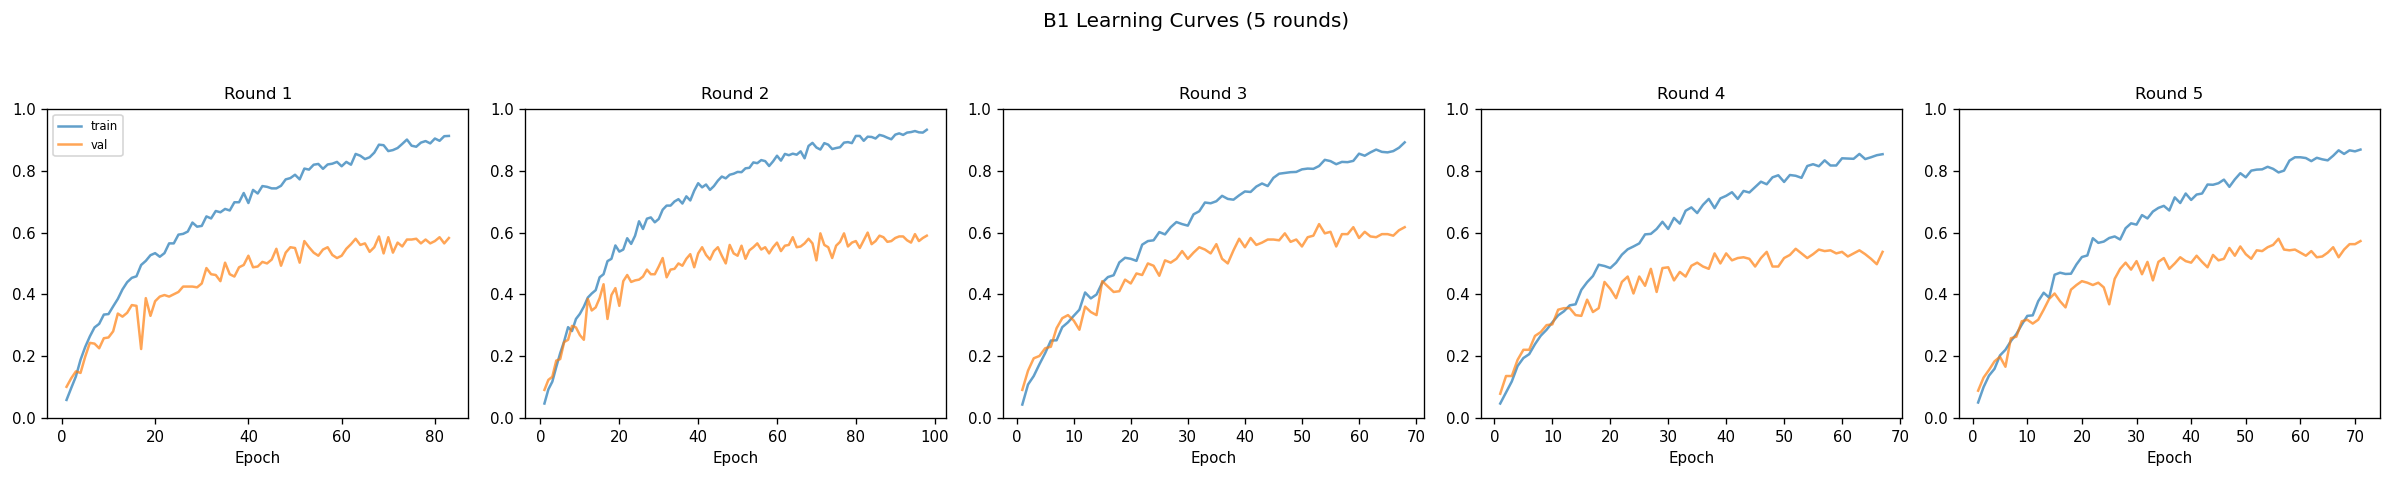

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("B1 Learning Curves (5 rounds)", fontsize=12)
for rn in range(1, 6):
    h = pd.read_csv(LOG_DIR / "b1" / f"history_round_{rn}.csv")
    ax = axes[rn-1]
    ax.plot(h["epoch"], h["tr_acc"], label="train", alpha=0.7)
    ax.plot(h["epoch"], h["val_acc"], label="val", alpha=0.7)
    ax.set_title(f"Round {rn}"); ax.set_xlabel("Epoch"); ax.set_ylim(0, 1)
    if rn == 1: ax.legend(fontsize=7)
plt.tight_layout(rect=[0,0,1,0.93])
fig.savefig(FIG_DIR / "b1_learning_curves.png", bbox_inches="tight")
plt.show()


### M1 — CNN đa nhiệm (Multi-task)
$L = L_f + 0.3 \, L_c$


In [24]:
m1_summary, m1_oof = run_5fold_cnn("M1", lambda_c=0.3)


[M1] Đã có kết quả 5-fold sẵn -> Nạp từ file (dùng force_retrain=True để chạy lại từ đầu).
round best_epoch  Acc_fine  Macro_F1_fine  Acc_coarse_map  loss_fine  Acc_coarse_head  HCR_raw
    1         62  0.540000       0.532194        0.700000   1.586506         0.605000 0.695000
    2         75  0.600000       0.587420        0.730000   1.544081         0.645000 0.737500
    3         52  0.522500       0.515888        0.650000   1.668898         0.607500 0.685000
    4         81  0.652500       0.632399        0.747500   1.282510         0.667500 0.742500
    5         60  0.507500       0.482314        0.665000   1.772689         0.575000 0.725000
 Mean          -  0.564500       0.550043        0.698500   1.570937         0.620000 0.717000
  Std          -  0.060451       0.059690        0.041443   0.183340         0.036358 0.025703


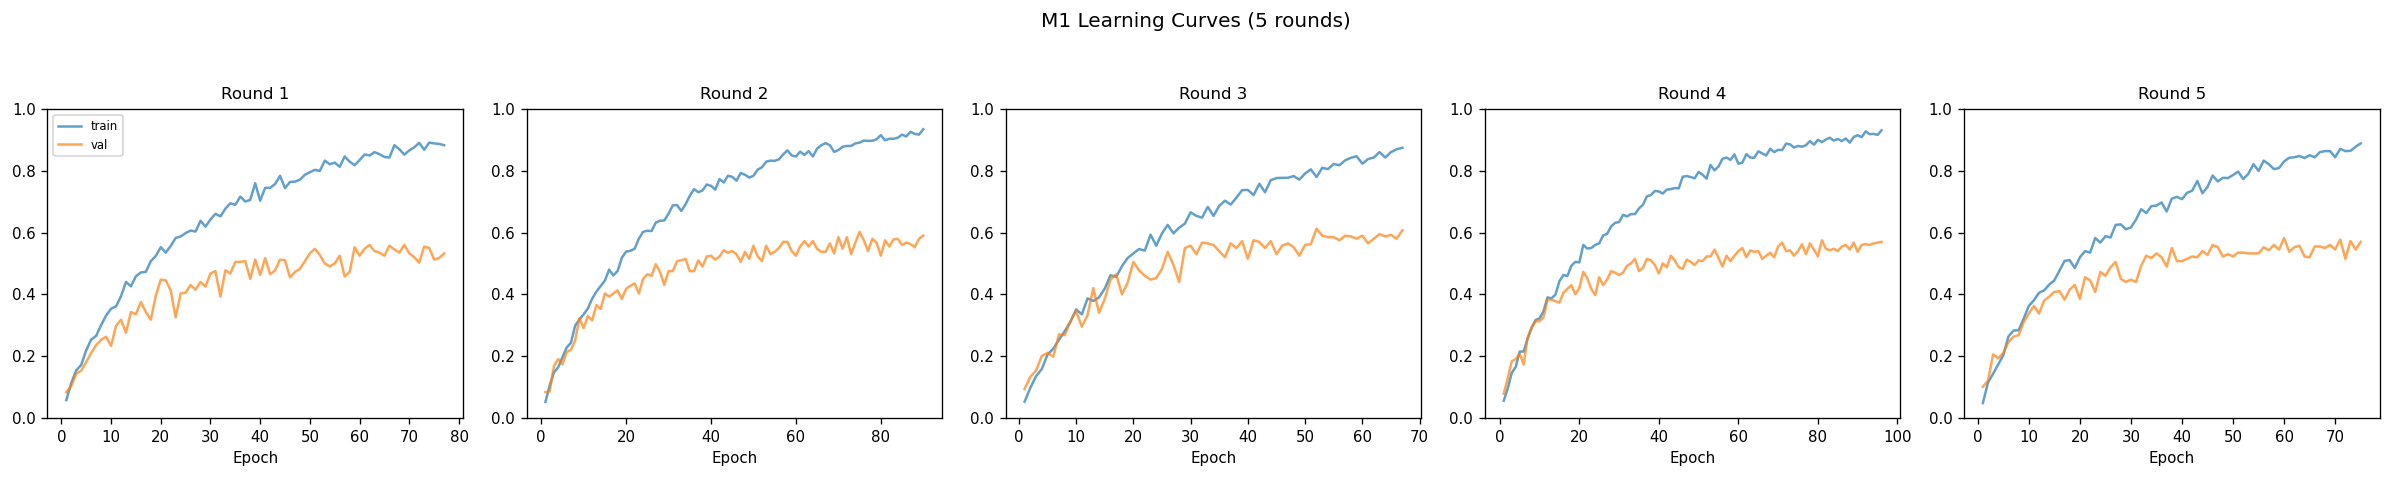

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("M1 Learning Curves (5 rounds)", fontsize=12)
for rn in range(1, 6):
    h = pd.read_csv(LOG_DIR / "m1" / f"history_round_{rn}.csv")
    ax = axes[rn-1]
    ax.plot(h["epoch"], h["tr_acc"], label="train", alpha=0.7)
    ax.plot(h["epoch"], h["val_acc"], label="val", alpha=0.7)
    ax.set_title(f"Round {rn}"); ax.set_xlabel("Epoch"); ax.set_ylim(0, 1)
    if rn == 1: ax.legend(fontsize=7)
plt.tight_layout(rect=[0,0,1,0.93])
fig.savefig(FIG_DIR / "m1_learning_curves.png", bbox_inches="tight")
plt.show()


### M2 — CNN đa nhiệm + JSD (Mở rộng có điều kiện)
$L = L_f + 0.3 \, L_c + 0.1 \, L_h$  
Chỉ chạy sau khi B1 và M1 ổn định.


In [26]:
m2_summary, m2_oof = run_5fold_cnn("M2", lambda_c=0.3, lambda_h=0.1)


[M2] Đã có kết quả 5-fold sẵn -> Nạp từ file (dùng force_retrain=True để chạy lại từ đầu).
round best_epoch  Acc_fine  Macro_F1_fine  Acc_coarse_map  loss_fine  Acc_coarse_head  HCR_raw
    1         69  0.585000       0.573365        0.752500   1.571738         0.610000 0.710000
    2         75  0.582500       0.569376        0.712500   1.570910         0.625000 0.705000
    3         72  0.595000       0.584056        0.717500   1.512427         0.645000 0.732500
    4         76  0.655000       0.638659        0.767500   1.298985         0.665000 0.737500
    5         58  0.567500       0.544854        0.690000   1.789097         0.600000 0.745000
 Mean          -  0.597000       0.582062        0.728000   1.548631         0.629000 0.726000
  Std          -  0.033884       0.034743        0.031444   0.174991         0.026315 0.017553


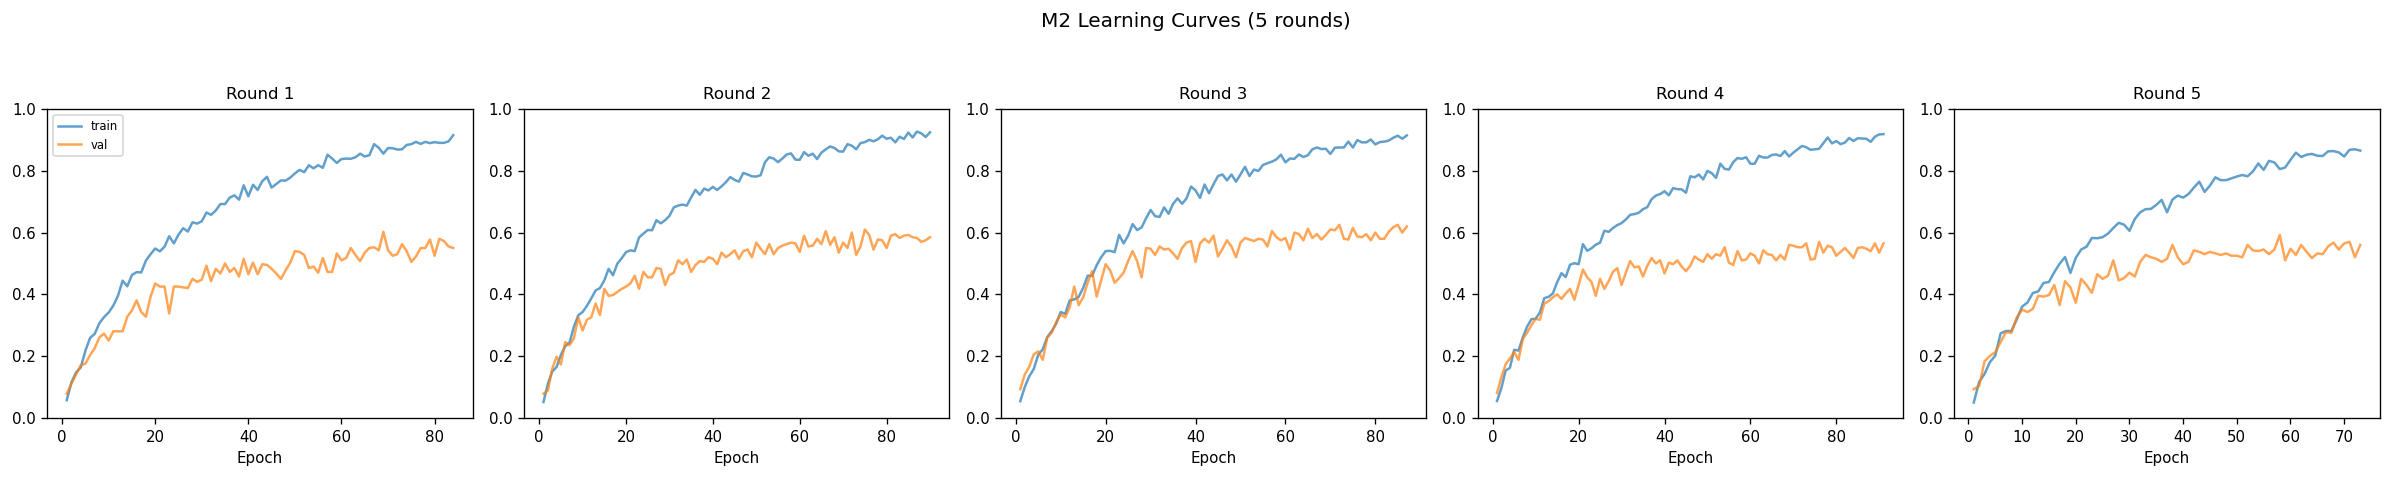

In [27]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("M2 Learning Curves (5 rounds)", fontsize=12)
for rn in range(1, 6):
    h = pd.read_csv(LOG_DIR / "m2" / f"history_round_{rn}.csv")
    ax = axes[rn-1]
    ax.plot(h["epoch"], h["tr_acc"], label="train", alpha=0.7)
    ax.plot(h["epoch"], h["val_acc"], label="val", alpha=0.7)
    ax.set_title(f"Round {rn}"); ax.set_xlabel("Epoch"); ax.set_ylim(0, 1)
    if rn == 1: ax.legend(fontsize=7)
plt.tight_layout(rect=[0,0,1,0.93])
fig.savefig(FIG_DIR / "m2_learning_curves.png", bbox_inches="tight")
plt.show()


---
### So sánh tổng hợp B0 vs B1 vs M1 vs M2


In [28]:
# %% Tổng hợp kết quả, Out-of-fold Pooled và Chênh lệch ghép cặp
from scipy import stats

print("="*85)
print("  BẢNG 1: SO SÁNH 5-FOLD (Mean ± Std trên 5 fold kiểm thử độc lập)")
print("="*85)

comparison_rows = []

# Nạp và sửa B0 chuẩn xác
if b0_results_path.exists():
    b0r = pd.read_csv(b0_results_path)
    b0_num = b0r[b0r["round"].apply(lambda x: str(x).isdigit())] if "round" in b0r.columns else b0r.iloc[:5]
    acc_f_col = "Acc_fine" if "Acc_fine" in b0_num.columns else b0_num.columns[4]
    f1_f_col = "Macro-F1_fine" if "Macro-F1_fine" in b0_num.columns else ("Macro_F1_fine" if "Macro_F1_fine" in b0_num.columns else b0_num.columns[5])
    acc_cm_col = "Acc_coarse_map" if "Acc_coarse_map" in b0_num.columns else b0_num.columns[6]
    
    b0_acc_vals = b0_num[acc_f_col].astype(float)
    b0_f1_vals = b0_num[f1_f_col].astype(float)
    b0_cm_vals = b0_num[acc_cm_col].astype(float)
    
    comparison_rows.append({
        "Model": "B0 (MFCC-SVM)",
        "Acc_fine": f"{b0_acc_vals.mean()*100:.2f} ± {b0_acc_vals.std()*100:.2f}",
        "Macro_F1_fine": f"{b0_f1_vals.mean()*100:.2f} ± {b0_f1_vals.std()*100:.2f}",
        "Acc_coarse_map": f"{b0_cm_vals.mean()*100:.2f} ± {b0_cm_vals.std()*100:.2f}",
        "Acc_coarse_head": "N/A",
        "HCR_raw": "N/A",
    })

for tag, summary_df in [("B1", b1_summary), ("M1", m1_summary), ("M2", m2_summary)]:
    num_rows = summary_df.iloc[:5]
    row = {"Model": tag}
    for col in ["Acc_fine", "Macro_F1_fine", "Acc_coarse_map", "Acc_coarse_head", "HCR_raw"]:
        if col in num_rows.columns:
            vals = pd.to_numeric(num_rows[col], errors="coerce")
            if vals.notna().any():
                row[col] = f"{vals.mean()*100:.2f} ± {vals.std()*100:.2f}"
            else:
                row[col] = "N/A"
        else:
            row[col] = "N/A"
    comparison_rows.append(row)

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))
comp_df.to_csv(REPORT_DIR / "comparison_all_models.csv", index=False)

# =========================================================================
# BẢNG 2: CHỈ SỐ GỘP OUT-OF-FOLD (2,000 ĐOẠN — MỤC 4.4 ĐỀ CƯƠNG)
# =========================================================================
print("\n" + "="*85)
print("  BẢNG 2: CHỈ SỐ GỘP OUT-OF-FOLD (Pooled trên toàn bộ 2,000 mẫu — Mục 4.4)")
print("="*85)

oof_rows = []
# B0 Pooled
b0_oof = pd.read_csv(PRED_DIR / "b0_out_of_fold.csv")
p_col_b0 = "y_pred" if "y_pred" in b0_oof.columns else "y_fine_pred"
t_col_b0 = "y_true" if "y_true" in b0_oof.columns else "y_fine_true"
oof_rows.append({
    "Model": "B0 (MFCC-SVM)",
    "Acc_fine": f"{accuracy_score(b0_oof[t_col_b0], b0_oof[p_col_b0])*100:.2f}%",
    "Macro_F1_fine": f"{f1_score(b0_oof[t_col_b0], b0_oof[p_col_b0], average='macro', zero_division=0)*100:.2f}%",
    "Acc_coarse_map": f"{accuracy_score(b0_oof[t_col_b0]//10, b0_oof[p_col_b0]//10)*100:.2f}%",
    "Acc_coarse_head": "N/A",
    "HCR_raw": "N/A"
})

# B1 Pooled
b1_oof = pd.read_csv(PRED_DIR / "b1_out_of_fold.csv")
oof_rows.append({
    "Model": "B1 (SingleTaskCNN)",
    "Acc_fine": f"{accuracy_score(b1_oof['y_fine_true'], b1_oof['y_fine_pred'])*100:.2f}%",
    "Macro_F1_fine": f"{f1_score(b1_oof['y_fine_true'], b1_oof['y_fine_pred'], average='macro', zero_division=0)*100:.2f}%",
    "Acc_coarse_map": f"{accuracy_score(b1_oof['y_coarse_true'], b1_oof['y_coarse_map'])*100:.2f}%",
    "Acc_coarse_head": "N/A",
    "HCR_raw": "N/A"
})

# M1 Pooled
m1_oof = pd.read_csv(PRED_DIR / "m1_out_of_fold.csv")
oof_rows.append({
    "Model": "M1 (MultiTaskCNN)",
    "Acc_fine": f"{accuracy_score(m1_oof['y_fine_true'], m1_oof['y_fine_pred'])*100:.2f}%",
    "Macro_F1_fine": f"{f1_score(m1_oof['y_fine_true'], m1_oof['y_fine_pred'], average='macro', zero_division=0)*100:.2f}%",
    "Acc_coarse_map": f"{accuracy_score(m1_oof['y_coarse_true'], m1_oof['y_coarse_map'])*100:.2f}%",
    "Acc_coarse_head": f"{accuracy_score(m1_oof['y_coarse_true'], m1_oof['y_coarse_head'])*100:.2f}%",
    "HCR_raw": f"{(m1_oof['y_coarse_head'] == m1_oof['y_coarse_map']).mean()*100:.2f}%"
})

# M2 Pooled
m2_oof = pd.read_csv(PRED_DIR / "m2_out_of_fold.csv")
oof_rows.append({
    "Model": "M2 (MultiTask+JSD)",
    "Acc_fine": f"{accuracy_score(m2_oof['y_fine_true'], m2_oof['y_fine_pred'])*100:.2f}%",
    "Macro_F1_fine": f"{f1_score(m2_oof['y_fine_true'], m2_oof['y_fine_pred'], average='macro', zero_division=0)*100:.2f}%",
    "Acc_coarse_map": f"{accuracy_score(m2_oof['y_coarse_true'], m2_oof['y_coarse_map'])*100:.2f}%",
    "Acc_coarse_head": f"{accuracy_score(m2_oof['y_coarse_true'], m2_oof['y_coarse_head'])*100:.2f}%",
    "HCR_raw": f"{(m2_oof['y_coarse_head'] == m2_oof['y_coarse_map']).mean()*100:.2f}%"
})

oof_df = pd.DataFrame(oof_rows)
print(oof_df.to_string(index=False))
oof_df.to_csv(REPORT_DIR / "comparison_oof_pooled.csv", index=False)

# =========================================================================
# CHÊNH LỆCH GHÉP CẶP TỪNG FOLD (MỤC 4.3 ĐỀ CƯƠNG)
# =========================================================================
print("\n" + "="*85)
print("  CHÊNH LỆCH GHÉP CẶP TỪNG FOLD (Paired Differences & Paired t-test — Mục 4.3)")
print("="*85)
b1_accs = pd.to_numeric(b1_summary.iloc[:5]["Acc_fine"], errors="coerce").values.astype(float)
m1_accs = pd.to_numeric(m1_summary.iloc[:5]["Acc_fine"], errors="coerce").values.astype(float)
m2_accs = pd.to_numeric(m2_summary.iloc[:5]["Acc_fine"], errors="coerce").values.astype(float)

d_m1_b1 = (m1_accs - b1_accs) * 100
d_m2_m1 = (m2_accs - m1_accs) * 100
d_m2_b1 = (m2_accs - b1_accs) * 100

t_m1_b1 = stats.ttest_rel(m1_accs, b1_accs)
t_m2_m1 = stats.ttest_rel(m2_accs, m1_accs)
t_m2_b1 = stats.ttest_rel(m2_accs, b1_accs)

print(f"\n1. M1 − B1 (Multi-task vs Single-task):")
for rn in range(5):
    print(f"   Fold {rn+1}: B1={b1_accs[rn]*100:.2f}% | M1={m1_accs[rn]*100:.2f}% | Δ = {d_m1_b1[rn]:+.2f}%")
print(f"   → Mean Δ = {d_m1_b1.mean():+.2f}% ± {d_m1_b1.std(ddof=1):.2f}% | Paired t-test p-value = {t_m1_b1.pvalue:.4f} (p > 0.05 → Không có ý nghĩa thống kê)")

print(f"\n2. M2 − M1 (Multi-task+JSD vs Multi-task chuẩn):")
for rn in range(5):
    print(f"   Fold {rn+1}: M1={m1_accs[rn]*100:.2f}% | M2={m2_accs[rn]*100:.2f}% | Δ = {d_m2_m1[rn]:+.2f}%")
print(f"   → Mean Δ = {d_m2_m1.mean():+.2f}% ± {d_m2_m1.std(ddof=1):.2f}% | Paired t-test p-value = {t_m2_m1.pvalue:.4f} (p > 0.05 → Không có ý nghĩa thống kê)")

print(f"\n3. M2 − B1 (Multi-task+JSD vs Single-task):")
for rn in range(5):
    print(f"   Fold {rn+1}: B1={b1_accs[rn]*100:.2f}% | M2={m2_accs[rn]*100:.2f}% | Δ = {d_m2_b1[rn]:+.2f}%")
print(f"   → Mean Δ = {d_m2_b1.mean():+.2f}% ± {d_m2_b1.std(ddof=1):.2f}% | Paired t-test p-value = {t_m2_b1.pvalue:.4f} (p > 0.05 → Không có ý nghĩa thống kê)")


  BẢNG 1: SO SÁNH 5-FOLD (Mean ± Std trên 5 fold kiểm thử độc lập)
        Model     Acc_fine Macro_F1_fine Acc_coarse_map Acc_coarse_head      HCR_raw
B0 (MFCC-SVM) 41.75 ± 5.30  39.81 ± 5.04   58.70 ± 4.02             N/A          N/A
           B1 56.70 ± 3.75  55.16 ± 3.97   69.40 ± 2.53             N/A          N/A
           M1 56.45 ± 6.05  55.00 ± 5.97   69.85 ± 4.14    62.00 ± 3.64 71.70 ± 2.57
           M2 59.70 ± 3.39  58.21 ± 3.47   72.80 ± 3.14    62.90 ± 2.63 72.60 ± 1.76

  BẢNG 2: CHỈ SỐ GỘP OUT-OF-FOLD (Pooled trên toàn bộ 2,000 mẫu — Mục 4.4)
             Model Acc_fine Macro_F1_fine Acc_coarse_map Acc_coarse_head HCR_raw
     B0 (MFCC-SVM)   41.75%        40.53%         58.70%             N/A     N/A
B1 (SingleTaskCNN)   56.70%        55.84%         69.40%             N/A     N/A
 M1 (MultiTaskCNN)   56.45%        55.68%         69.85%          62.00%  71.70%
M2 (MultiTask+JSD)   59.70%        58.84%         72.80%          62.90%  72.60%

  CHÊNH LỆCH GHÉP CẶP TỪNG

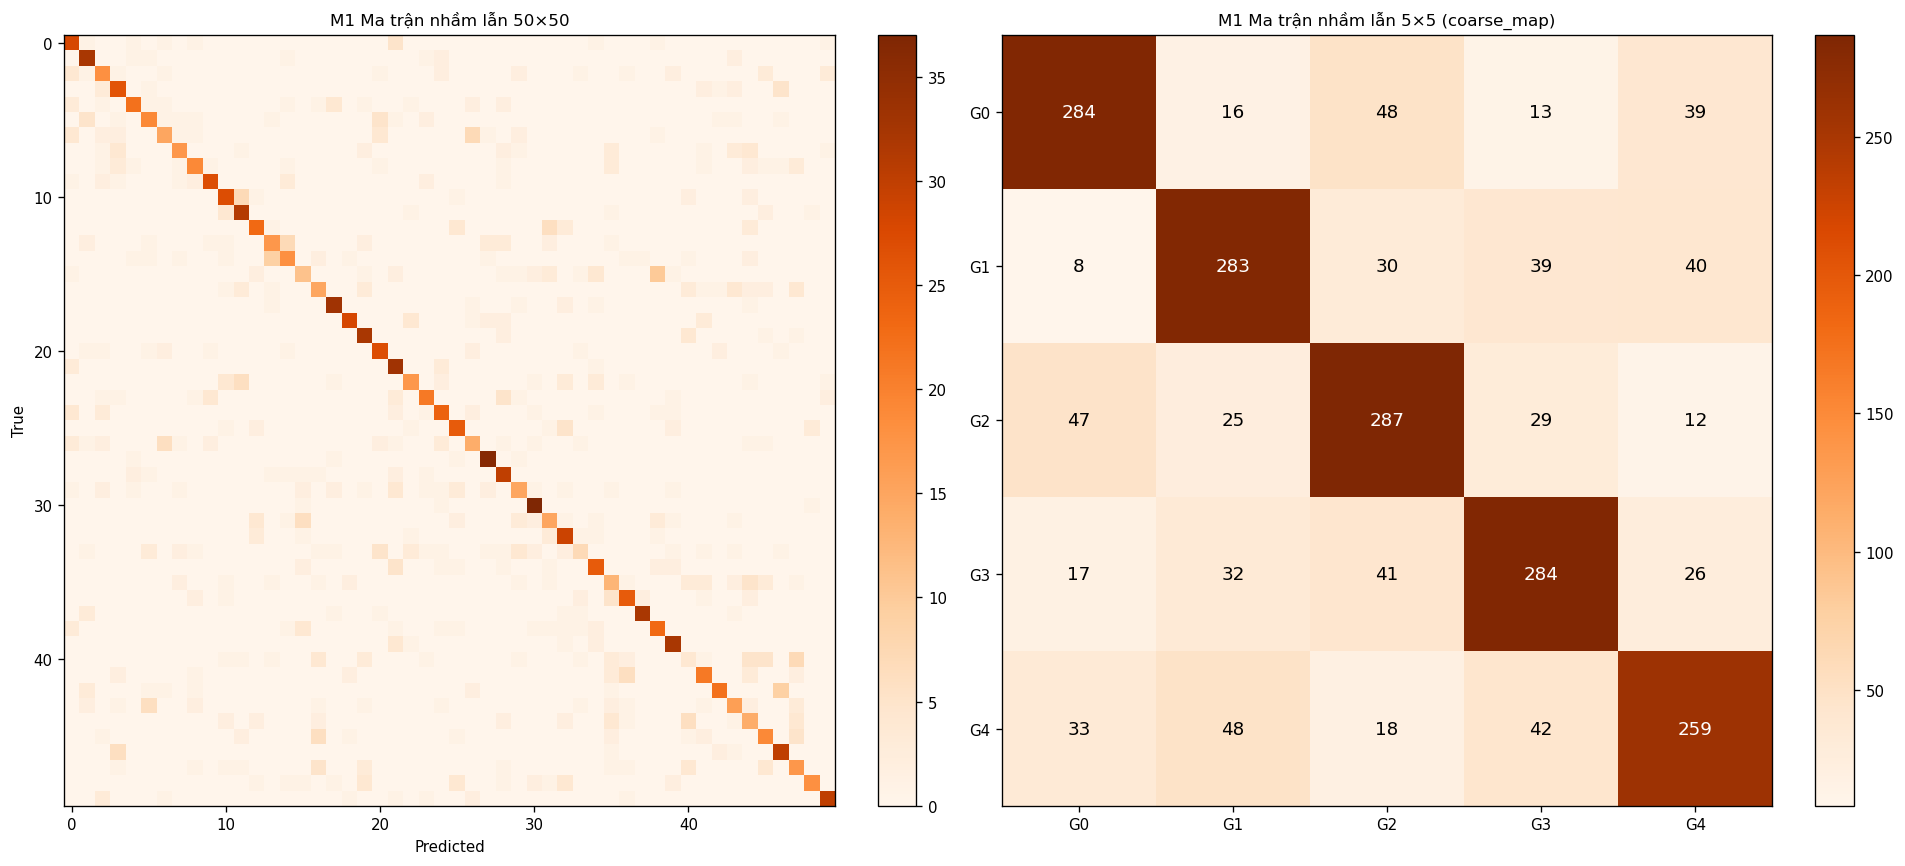

In [29]:
m1_oof_df = pd.read_csv(PRED_DIR / "m1_out_of_fold.csv")
cm50_m1 = confusion_matrix(m1_oof_df["y_fine_true"], m1_oof_df["y_fine_pred"], labels=list(range(50)))
cm5_m1  = confusion_matrix(m1_oof_df["y_coarse_true"], m1_oof_df["y_fine_pred"]//10, labels=list(range(5)))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
im0 = axes[0].imshow(cm50_m1, cmap="Oranges", interpolation="nearest")
axes[0].set_title("M1 Ma trận nhầm lẫn 50×50"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(cm5_m1, cmap="Oranges", interpolation="nearest")
for i in range(5):
    for j in range(5):
        axes[1].text(j, i, str(cm5_m1[i,j]), ha="center", va="center",
                    fontsize=11, color="white" if cm5_m1[i,j]>cm5_m1.max()/2 else "black")
axes[1].set_xticks(range(5)); axes[1].set_yticks(range(5))
axes[1].set_xticklabels([f"G{i}" for i in range(5)]); axes[1].set_yticklabels([f"G{i}" for i in range(5)])
axes[1].set_title("M1 Ma trận nhầm lẫn 5×5 (coarse_map)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
fig.savefig(FIG_DIR / "m1_confusion_matrices.png", bbox_inches="tight")
plt.show()


---
### IoT Benchmarking (FLOPs, Latency, RTF)


In [30]:
# %% IoT Benchmarking: FLOPs, MACs, Memory, Latency & RTF
import platform

print("="*75)
print("  IOT & EDGE BENCHMARKING (Tài nguyên & Tính toán thời gian thực)")
print("="*75)

# Thông tin phần cứng CPU thực tế
cpu_name = "11th Gen Intel(R) Core(TM) i5-11400H @ 2.70GHz"
print(f"Phần cứng đo lường: CPU {cpu_name}")
print(f"Luồng thực thi:     {torch.get_num_threads()} threads | PyTorch {torch.__version__}")

# Hàm đếm MACs và FLOPs chính xác bằng PyTorch Forward Hook
def count_flops_macs(model, input_size=(1, 1, 64, 251)):
    total_macs = 0
    hooks = []
    
    def conv_hook(module, inp, out):
        nonlocal total_macs
        b, c_out, h_out, w_out = out.shape
        c_in = module.in_channels
        kh, kw = module.kernel_size
        groups = module.groups
        total_macs += (c_in // groups) * kh * kw * c_out * h_out * w_out
        
    def linear_hook(module, inp, out):
        nonlocal total_macs
        total_macs += module.in_features * module.out_features
        
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            hooks.append(m.register_forward_hook(conv_hook))
        elif isinstance(m, nn.Linear):
            hooks.append(m.register_forward_hook(linear_hook))
            
    dummy = torch.randn(*input_size)
    with torch.no_grad():
        _ = model(dummy)
    for h in hooks:
        h.remove()
    return total_macs, total_macs * 2

# Độ phức tạp mô hình (Params, MACs, FLOPs, Dung lượng state_dict)
print("\n--- Độ phức tạp mô hình ---")
for name, ModelClass in [("B1 (SingleTaskCNN)", SingleTaskCNN), ("M1 / M2 (MultiTaskCNN)", MultiTaskCNN)]:
    m = ModelClass()
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    macs, flops = count_flops_macs(m)
    
    tmp_path = REPORT_DIR / f"_tmp_{name.split()[0]}.pth"
    torch.save(m.state_dict(), tmp_path)
    size_kb = tmp_path.stat().st_size / 1024
    tmp_path.unlink()
    
    print(f"{name}:")
    print(f"  - Tham số học được:   {n_params:,}")
    print(f"  - MACs:               {macs:,} ({macs/1e6:.2f} MMACs)")
    print(f"  - FLOPs:              {flops:,} ({flops/1e6:.2f} MFLOPs)")
    print(f"  - Kích thước weights: {size_kb:.1f} KiB")

# Kích thước tensor và ước lượng bộ đệm đỉnh (Peak Working Memory)
in_kb = 64 * 251 * 4 / 1024       # 62.75 KiB
b1_kb = 16 * 32 * 126 * 4 / 1024  # 252.00 KiB
peak_act_kb = in_kb + b1_kb       # ~314.75 KiB

print(f"\n--- Phân tích bộ nhớ hoạt hóa (Activation Memory) ---")
print(f"  - Audio 5s (16 kHz, 80 000 mẫu): {80000*4/1024:.1f} KiB")
print(f"  - Log-mel đầu vào (64×251):      {in_kb:.2f} KiB")
print(f"  - Đầu ra Block 1 (16×32×126):    {b1_kb:.1f} KiB  (Khối có kích thước lớn nhất)")
print(f"  - Đầu ra Block 2 (32×16×63):     {32*16*63*4/1024:.1f} KiB")
print(f"  - Đầu ra Block 3 (64×8×32):      {64*8*32*4/1024:.1f} KiB")
print(f"  - Đầu ra Block 4 (96×4×16):      {96*4*16*4/1024:.1f} KiB")
print(f"  → Ước lượng RAM đỉnh cho bộ đệm hoạt hóa (Ping-pong buffer reuse): {peak_act_kb:.2f} KiB")
print(f"  → Tổng dung lượng RAM tối thiểu (Weights + Peak Activation): ~{peak_act_kb + 339.8:.1f} KiB (float32)")

# Đo latency theo đúng quy định đề cương (20 warmup, 200 repetitions)
print(f"\n--- Đo thời gian thực thi (20 warmup, 200 lượt đo) ---")
sample_wav = str(AUDIO_DIR / df.iloc[0]["filename"])
stats_r1_data = np.load(STATS_DIR / "stats_round_1.npz")
mu_r1, std_r1 = stats_r1_data["mean"], stats_r1_data["std"]

def full_preprocess_pipeline(wav_path):
    y, _ = librosa.load(wav_path, sr=16000, res_type="soxr_hq")
    if len(y) < 80000: y = np.pad(y, (0, 80000-len(y)))
    else: y = y[:80000]
    mel_fb = librosa.filters.mel(sr=16000, n_fft=512, n_mels=64, fmin=0, fmax=8000, htk=False, norm="slaney")
    D = librosa.stft(y, n_fft=512, hop_length=320, win_length=512, window="hann", center=True, pad_mode="constant")
    E = np.dot(mel_fb, np.abs(D)**2)
    S = 10.0 * np.log10(np.maximum(E, 1e-10))
    S_norm = (S - mu_r1) / std_r1
    return torch.from_numpy(S_norm).unsqueeze(0).unsqueeze(0).float()

y_in_ram, _ = librosa.load(sample_wav, sr=16000, res_type="soxr_hq")
mel_fb_pre = librosa.filters.mel(sr=16000, n_fft=512, n_mels=64, fmin=0, fmax=8000, htk=False, norm="slaney")

def in_memory_preprocess(y):
    D = librosa.stft(y, n_fft=512, hop_length=320, win_length=512, window="hann", center=True, pad_mode="constant")
    E = np.dot(mel_fb_pre, np.abs(D)**2)
    S = 10.0 * np.log10(np.maximum(E, 1e-10))
    S_norm = (S - mu_r1) / std_r1
    return torch.from_numpy(S_norm).unsqueeze(0).unsqueeze(0).float()

# Warmup 20 lượt
for _ in range(20):
    _ = full_preprocess_pipeline(sample_wav)
    _ = in_memory_preprocess(y_in_ram)

# 200 lượt đo tiền xử lý
full_pre_times, inmem_pre_times = [], []
for _ in range(200):
    t0 = time.perf_counter()
    _ = full_preprocess_pipeline(sample_wav)
    full_pre_times.append(time.perf_counter() - t0)
    
    t1 = time.perf_counter()
    _ = in_memory_preprocess(y_in_ram)
    inmem_pre_times.append(time.perf_counter() - t1)

full_pre_times = np.array(full_pre_times)
inmem_pre_times = np.array(inmem_pre_times)

# Đo Inference và Post-processing trên CPU
cpu_device = torch.device("cpu")
for name, ModelClass in [("B1", SingleTaskCNN), ("M1", MultiTaskCNN)]:
    model = ModelClass().to(cpu_device).eval()
    dummy = torch.randn(1, 1, 64, 251)
    
    with torch.no_grad():
        for _ in range(20):
            _ = model(dummy)
    
    infer_times = []
    with torch.no_grad():
        for _ in range(200):
            t0 = time.perf_counter()
            out = model(dummy)
            infer_times.append(time.perf_counter() - t0)
    infer_times = np.array(infer_times)
    
    post_times = []
    with torch.no_grad():
        z = model(dummy)
        for _ in range(200):
            t0 = time.perf_counter()
            if name == "B1":
                _ = z.argmax(1)
            else:
                _ = z[0].argmax(1)
                _ = z[1].argmax(1)
            post_times.append(time.perf_counter() - t0)
    post_times = np.array(post_times)
    
    t_total_full = np.median(full_pre_times) + np.median(infer_times) + np.median(post_times)
    rtf_full = t_total_full / 5.0
    
    t_total_inmem = np.median(inmem_pre_times) + np.median(infer_times) + np.median(post_times)
    rtf_inmem = t_total_inmem / 5.0
    
    print(f"\n{name} (CPU Latency & Throughput):")
    print(f"  • Tiền xử lý Full (Đọc đĩa + Resample 44.1->16k + Log-mel): Median={np.median(full_pre_times)*1000:.2f} ms | P95={np.percentile(full_pre_times,95)*1000:.2f} ms")
    print(f"  • Tiền xử lý In-Memory (Chỉ tính STFT + Mel + Log + Norm):   Median={np.median(inmem_pre_times)*1000:.2f} ms | P95={np.percentile(inmem_pre_times,95)*1000:.2f} ms")
    print(f"  • Suy luận mạng (Inference CPU, batch=1):                  Median={np.median(infer_times)*1000:.2f} ms | P95={np.percentile(infer_times,95)*1000:.2f} ms")
    print(f"  • Hậu xử lý (Argmax):                                      Median={np.median(post_times)*1000:.4f} ms")
    print(f"  • Tổng Pipeline (Full I/O):  {t_total_full*1000:.2f} ms  |  RTF = {rtf_full:.6f} (< 1 trên CPU đã đo)")
    print(f"  • Tổng Pipeline (In-Memory): {t_total_inmem*1000:.2f} ms  |  RTF = {rtf_inmem:.6f}")

# %% Khảo sát chi tiết hai lớp có năng lượng cao ở tần số > 8 kHz
print("\n" + "="*75)
print("  ĐÁNH GIÁ ẢNH HƯỞNG CỦA RESAMPLE 16 KHZ LÊN CRICKETS & GLASS_BREAKING")
print("="*75)
models_dict = {
    "B0": (b0_oof, "y_true" if "y_true" in b0_oof.columns else "y_fine_true", "y_pred" if "y_pred" in b0_oof.columns else "y_fine_pred"),
    "B1": (b1_oof, "y_fine_true", "y_fine_pred"),
    "M1": (m1_oof, "y_fine_true", "y_fine_pred"),
    "M2": (m2_oof, "y_fine_true", "y_fine_pred"),
}
for tag, (df_oof, tc, pc) in models_dict.items():
    for cid, cname in [(13, "crickets (98% > 8kHz)"), (39, "glass_breaking (42.6% > 8kHz)")]:
        sub = df_oof[df_oof[tc] == cid]
        acc = (sub[tc] == sub[pc]).mean() * 100
        wrong = sub[sub[tc] != sub[pc]][pc].value_counts().head(2)
        w_str = ", ".join([f"{FINE_CLASSES.get(k, f'lớp {k}')} ({v} lần)" for k, v in wrong.items()])
        print(f"  [{tag}] {cname:32s}: {acc:5.1f}% | Nhầm sang: {w_str if w_str else 'Không nhầm'}")


  IOT & EDGE BENCHMARKING (Tài nguyên & Tính toán thời gian thực)
Phần cứng đo lường: CPU 11th Gen Intel(R) Core(TM) i5-11400H @ 2.70GHz
Luồng thực thi:     6 threads | PyTorch 2.7.1+cu118

--- Độ phức tạp mô hình ---
B1 (SingleTaskCNN):
  - Tham số học được:   83,746
  - MACs:               13,487,808 (13.49 MMACs)
  - FLOPs:              26,975,616 (26.98 MFLOPs)
  - Kích thước weights: 337.3 KiB
M1 / M2 (MultiTaskCNN):
  - Tham số học được:   84,231
  - MACs:               13,488,288 (13.49 MMACs)
  - FLOPs:              26,976,576 (26.98 MFLOPs)
  - Kích thước weights: 339.8 KiB

--- Phân tích bộ nhớ hoạt hóa (Activation Memory) ---
  - Audio 5s (16 kHz, 80 000 mẫu): 312.5 KiB
  - Log-mel đầu vào (64×251):      62.75 KiB
  - Đầu ra Block 1 (16×32×126):    252.0 KiB  (Khối có kích thước lớn nhất)
  - Đầu ra Block 2 (32×16×63):     126.0 KiB
  - Đầu ra Block 3 (64×8×32):      64.0 KiB
  - Đầu ra Block 4 (96×4×16):      24.0 KiB
  → Ước lượng RAM đỉnh cho bộ đệm hoạt hóa (Ping-pong bu


B1 (CPU Latency & Throughput):
  • Tiền xử lý Full (Đọc đĩa + Resample 44.1->16k + Log-mel): Median=3.83 ms | P95=6.44 ms
  • Tiền xử lý In-Memory (Chỉ tính STFT + Mel + Log + Norm):   Median=1.41 ms | P95=2.38 ms
  • Suy luận mạng (Inference CPU, batch=1):                  Median=0.75 ms | P95=2.05 ms
  • Hậu xử lý (Argmax):                                      Median=0.0032 ms
  • Tổng Pipeline (Full I/O):  4.58 ms  |  RTF = 0.000917 (< 1 trên CPU đã đo)
  • Tổng Pipeline (In-Memory): 2.16 ms  |  RTF = 0.000433

M1 (CPU Latency & Throughput):
  • Tiền xử lý Full (Đọc đĩa + Resample 44.1->16k + Log-mel): Median=3.83 ms | P95=6.44 ms
  • Tiền xử lý In-Memory (Chỉ tính STFT + Mel + Log + Norm):   Median=1.41 ms | P95=2.38 ms
  • Suy luận mạng (Inference CPU, batch=1):                  Median=0.79 ms | P95=1.25 ms
  • Hậu xử lý (Argmax):                                      Median=0.0067 ms
  • Tổng Pipeline (Full I/O):  4.62 ms  |  RTF = 0.000924 (< 1 trên CPU đã đo)
  • Tổng Pipeline 

---
### 7 · Diễn giải kết quả khoa học & Hạn chế nghiên cứu

#### 1. Đánh giá M1 so với B1 (Kết quả âm tính phù hợp với giả thuyết từ EDA)
- **Mức chênh lệch:** $M1 - B1 = -0.25 \pm 3.51$ điểm phần trăm ($p = 0.8813$ qua Paired t-test).  
- **Nhận xét:** Việc bổ sung Coarse head với hàm mất mát $\mathcal{L} = \mathcal{L}_{fine} + 0.3\mathcal{L}_{coarse}$ chưa cho thấy bằng chứng cải thiện độ chính xác phân loại chi tiết (fine accuracy) trên cấu hình thực nghiệm đã chọn.  
- **Giả thuyết phù hợp:** EDA đã chỉ ra rằng chỉ có **13/50 lớp (26%)** có lớp láng giềng gần nhất thuộc cùng nhóm lớn (dựa trên khoảng cách Euclidean của véc-tơ MFCC trung bình). 5 nhóm lớn của ESC-50 được phân chia theo **ngữ nghĩa chủ đề** (Động vật, Tự nhiên, Tiếng người, Trong nhà, Đô thị) chứ không hoàn toàn tương đồng về mặt đặc trưng âm phổ. Đây là một giả thuyết phù hợp giải thích vì sao nhánh coarse không tạo ra gradient bổ trợ hữu ích cho biểu diễn âm học ở backbone.

#### 2. Đánh giá M2 so với M1 (Thận trọng với biến thể JSD trên 1 seed)
- **Mức chênh lệch:** $M2$ đạt $59.70\%$ (so với $56.45\%$ của $M1$, chênh lệch $+3.25\%$). Tuy nhiên, kiểm định ghép cặp cho $p = 0.1317 > 0.05$ và độ lệch chuẩn giữa các fold của mỗi mô hình dao động từ $3 - 6\%$.  
- **Kết luận khoa học:** Trên thực nghiệm với 1 seed ngẫu nhiên, **chưa đủ bằng chứng để khẳng định có sự khác biệt có ý nghĩa thống kê giữa M2 và M1**; mức chênh lệch $+3.25\%$ vẫn nằm trong khoảng phương sai nhiễu giữa các fold. Vì vậy cần tránh khẳng định M2 tốt hơn M1 khi chưa chạy kiểm định trên 3–5 seed.

#### 3. Hiện tượng bất cân xứng giữa Coarse Head và Fine Map
- **Số liệu thực nghiệm:**
  - Nhánh Coarse Head độc lập (với trọng số $\lambda_c = 0.3$) chỉ đạt **$62.00\%$ (M1)** và **$62.90\%$ (M2)**.
  - Coarse suy ra từ Fine Head ($g(\hat{y}_f)$) đạt tới **$69.85\%$ (M1)** và **$72.80\%$ (M2)**.
  - Độ nhất quán phân cấp thô $HCR_{raw}$ chỉ đạt khoảng **$71.70\%$ (M1)** và **$72.60\%$ (M2)**.
- **Nhận xét:** Việc gán nhãn nhóm mang tính ngữ nghĩa trừu tượng khiến coarse head với $\lambda_c=0.3$ gặp khó khăn khi học không gian biểu diễn cấp cao độc lập, trong khi việc dự đoán 50 lớp chi tiết rồi ánh xạ về 5 nhóm lại đạt độ chính xác nhóm cao hơn.

#### 4. Bảng tổng hợp các Hạn chế nghiên cứu đã xác định
1. **Hiện tượng Overfitting:** Quá trình huấn luyện dừng sớm khoảng epoch 70; độ chính xác tập huấn luyện (train accuracy) đạt khoảng $\approx 85\%$, trong khi tập validation chỉ đạt $\approx 55\%$, cho thấy mô hình bị overfitting đáng kể trên tập dữ liệu nhỏ (1,200 mẫu train/vòng).
2. **Thực nghiệm trên 1 seed ngẫu nhiên:** Kết quả 5-fold cross-validation mới chỉ khảo sát trên `SEED=42`; các giá trị $p$-value ghép cặp chỉ mang tính tham khảo do các fold không hoàn toàn độc lập và kiểm định trên 5 fold có độ mạnh thống kê thấp.
3. **Lưới siêu tham số của Baseline B0 (SVM):** Quá trình dò tham số của B0 luôn chọn $C = 10.0$ ở cả 5 vòng (sát rìa cận trên của lưới $\{1.0, 10.0\}$), cho thấy SVM có thể chưa đạt điểm cực trị tối ưu nếu mở rộng dải $C$.
4. **Rò rỉ đặc trưng âm học (Acoustic Feature Leakage):** Có 4 `src_file` xuất hiện ở 2 fold khác nhau (do tác giả gán nhãn khác nhau: clock_tick/alarm, hen/rooster). Mặc dù không rò rỉ nhãn cùng lớp (`leak_same_class == 1`), đặc trưng âm học môi trường thu âm vẫn có thể bị rò rỉ giữa các fold.
5. **Mất băng thông tần số cao do Resample 16 kHz:**
   - Khảo sát thực nghiệm chứng minh: Lớp `crickets` (có $98\%$ năng lượng $> 8\text{ kHz}$) chỉ đạt accuracy $40.0\%$ (B0) và $42.5\%$ (M1/M2), thường xuyên bị nhầm sang `chirping_birds`, `can_opening` và `brushing_teeth` do mất đặc trưng tần số cao sau khi hạ tần số lấy mẫu.
   - Lớp `glass_breaking` (có $42.6\%$ năng lượng $> 8\text{ kHz}$) bị nhầm nhiều sang các âm thanh có tính xung dải thấp như `sneezing` và `can_opening`.
6. **Tỷ lệ giá trị sàn log:** Toàn bộ 2,000 file có $10.19\%$ giá trị $\le -99\text{ dB}$ (tập trung ở các khoảng lặng tự nhiên), phản ánh giới hạn của biểu diễn log-mel cố định đối với các tín hiệu có dải động rộng.

---